# Download and prepare `TA` (2004-2025)

**notebook version**: `7` (28 Jul 2026)

## ℹ️ About this notebook

Downloads screened air temperature `TA` from InfluxDB, merges the sources into one continuous
series, corrects the 2012 logger timestamp shift, gap-fills, and writes the product to the
external data folder.

Same shape as notebook `01` (`SW_IN`), but the gap-filler differs: `TA` uses the general
`XGBoostTS`, not the radiation-specific `SWINGapFillerXGBoost` (see *Method*).

**The 47 m record is not one instrument.** On 21 January 2016 the sensor and the acquisition
system were replaced together, and the series steps by about 1.3 °C at that date. The step is
larger than the warming signal it sits inside, so any statistic that spans it — a period mean, a
trend, a ranking of years — is dominated by the instrument rather than by the climate unless the
break is handled. The section *The 2016 acquisition break* establishes this from the data, the two
logger programs and the fieldbook, and derives the correction. A homogenised column and a source
flag are exported alongside the measured series.

The correction has **two terms**, because the change had two parts. A constant removes the
zero-point error of the old analog acquisition, which acted day and night. A radiation-dependent
term removes the difference between the two sensors' radiation shields, which acts only in sun and
which no constant can reach; it is fitted against the aspirated NABEL sensor on the same tower.
The alternatives to this construction are scored in `TA_HOMOGENIZATION_OPTIONS.ipynb`.

**Output columns:**

- `TA_T1_47_1_gfXG` — the gap-filled series as measured (°C, complete). **Not homogeneous across
  21 January 2016.**
- `FLAG_TA_T1_47_1_ISFILLED` — `0` = measured, `>0` = filled (codes in `FLAG_LEGEND` below)
- `TA_T1_47_1_HOMOGENIZED_gfXG` — the same series made comparable across the sensor change:
  the pre-2016 era raised onto the night level of the post-2016 era by a constant, and the
  post-2016 era freed of the extra warming its radiation shield produces in sun.
  **Use this column for anything that crosses 2016.**
- `FLAG_TA_T1_47_1_SOURCE` — which sensor and acquisition system a value belongs to (codes in
  `FLAG_SOURCE_LEGEND` below)

**Fill quality is not uniform, and the gap-filling is split at the sensor change.** Three models
are fitted, one per period: 2004 to the changeover (MP101A, with NABEL as a driver), the
changeover to the end of 2018 (CS215, with NABEL), and 2019 onwards (CS215, without NABEL). No
model is trained across the sensor change, which is what makes the homogenisation valid for
modelled records as well as measured ones.

Downloading uses diive's `InfluxIO`, which needs `influxdb-client`; `uv sync` installs it here via
the `diive[db]` extra.


***

## 📇 Data sources

**Series**

- `TA_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2005-2021), diive (2022-2025).
  Two sensors, not one: a **Rotronic MP101A** read as an analog single-ended voltage until
  31 December 2015, and a **Campbell CS215** read over SDI-12 from 21 January 2016. The section
  *The 2016 acquisition break* identifies both from the logger programs
- `TA_NABEL_T1_49_1` — NABEL, 49 m, same tower. Available to ~2018. Gap-filling driver, and the
  reference that resolves the 2016 break, because it spans the break on the same tower
- `TA_LAE_MS` — MeteoSwiss Lägern, 2.5 km, 845 m, 2004-2025. Gap-filling driver, read from the
  product written by `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`. Independent confirmation that
  it is the tower sensor that moved in 2016 and not NABEL
- `SW_IN_LAE_MS`, `WS_LAE_MS` — incoming shortwave and wind speed at the same MeteoSwiss
  station, from the same file. Not drivers: the break section bins the residual between the
  two stations by them, to establish that what survives the homogenisation is radiative
- `SW_IN_T1_47_1_gfXG` — gap-filled `SW_IN` from notebook `01`. Gap-filling driver over the
  whole record, and the variable the radiation-dependent part of the homogenisation is a function
  of, so notebook `01` must be run first

Gap-filling is XGBoost; potential radiation and timestamp features are added by the gap-filler.

**Files on disk**

The two logger programs are read in the break section rather than quoted, so the sensor identity
and its calibration constants can be re-checked instead of taken on trust:

- `csi_loggerscripts/LAEGEREN.20060524.csi` — the CR10X program of the pre-2016 acquisition
- `logger_scripts/ch-lae_idl_t1_47_1-Version_20160118/CH-LAE_iDL_T1_47_1.CR1` — the CR1000
  program installed at the changeover

**Legend**

- NABEL ... [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... ETH data, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... ETH data, meteoscreening with diive


## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "02_METEO_TA_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Gap-filled SW_IN produced by notebook 01, used here as a driver.
SWIN_FILE = "01_METEO_SW_IN_GAPFILLED_2004-2025"
SWIN_COL = "SW_IN_T1_47_1_gfXG"

# Reference: MeteoSwiss Lägern, 2.5 km from the tower. Produced by
# 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb. Addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "TA_LAE_MS"
# Two further columns of the same reference file. They measure nothing at the tower and
# are not drivers; the break section bins the residual between the two stations by them,
# to show what the homogenisation leaves behind and what it scales with.
REFCOL_SW = "SW_IN_LAE_MS"
REFCOL_WS = "WS_LAE_MS"

# --- Inputs for the 2016 acquisition break -----------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# The two logger programs that bracket the changeover. Read rather than quoted, so the sensor
# identity and the calibration constants are re-derived on every run.
PROGRAM_BEFORE = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                  r"\csi_loggerscripts\LAEGEREN.20060524.csi")
PROGRAM_AFTER = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")


### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau, theilslopes

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-28 19:15:13
diive version: v0.91.0


### Helpers

In [3]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn.

    A figure with a layout engine makes room for a caption itself. The heatmaps diive builds have
    no engine, and a caption placed in one lands on top of the tick labels; for those the figure
    is extended downwards and every axes moved up by the same amount, so the drawing keeps its
    size and position and the caption gets a free strip below it.
    """
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    if fig.get_layout_engine() is not None:
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

In [4]:
# Result flags used in this notebook.
# 0/1/2 are the standard diive gap-filling flags (see GapFillingResult). 4 is added by the
# short-gap interpolation step below and uses the same code as in notebook 01, so both
# products speak the same language. There is no flag 3 here: that is the nighttime-zero
# branch of the SW_IN gap-filler, which does not apply to temperature.
#
# 5 is specific to this notebook. The fallback model (code 2) predicts from the timestamp alone,
# so it follows the season but not the weather; where NABEL is available those records are
# reconstructed from it instead, and re-coded. See the export section.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = gap-filled by the XGBoost model',
    2: '2 = gap-filled by the timestamp-only fallback model (a driver was missing)',
    4: '4 = gap-filled by linear interpolation (short gap)',
    5: '5 = reconstructed from NABEL at 49 m on the same tower (the model lacked a driver)',
}
FILL_OBSERVED = 0
FILL_FALLBACK = 2
FILL_FROM_NABEL = 5

# Provenance flag, added in version 4. It is NOT the ISFILLED flag above, which names the model
# that produced a value: this one names the physical instrument the value came from, because the
# two sensor eras are not interchangeable. Same idea as FLAG_PREC_TOT_T1_47_1_SOURCE in notebook
# 08, and for the same reason - one field name spanning two acquisition systems.
#
# Codes 2 and 3 both mark records that no sensor produced, and they are separate because the
# reasons differ. Code 2 is the outage the changeover happened inside: no evidence assigns it to
# either sensor, so it is not assigned (notebook 08 treats its 71 unresolved transition days the
# same way). Code 3 is the period before the tower record begins at all.
FLAG_SOURCE_LEGEND = {
    0: '0 = Campbell CS215, SDI-12, 21 Jan 2016 onwards (the reference era of the homogenisation)',
    1: '1 = Rotronic MP101A, analog single-ended, 2004 - 31 Dec 2015 (reads about 1.3 degC low)',
    2: '2 = acquisition changeover, 01 - 21 Jan 2016: no measurement, sensor era undetermined',
    3: '3 = before the tower record begins (2004): no measurement, values are modelled throughout',
}
SOURCE_CS215 = 0
SOURCE_MP101A = 1
SOURCE_CHANGEOVER = 2
SOURCE_PRERECORD = 3

for _v in FLAG_LEGEND.values():
    print(_v)
print()
for _v in FLAG_SOURCE_LEGEND.values():
    print(_v)


0 = observed
1 = gap-filled by the XGBoost model
2 = gap-filled by the timestamp-only fallback model (a driver was missing)
4 = gap-filled by linear interpolation (short gap)
5 = reconstructed from NABEL at 49 m on the same tower (the model lacked a driver)

0 = Campbell CS215, SDI-12, 21 Jan 2016 onwards (the reference era of the homogenisation)
1 = Rotronic MP101A, analog single-ended, 2004 - 31 Dec 2015 (reads about 1.3 degC low)
2 = acquisition changeover, 01 - 21 Jan 2016: no measurement, sensor era undetermined
3 = before the tower record begins (2004): no measurement, values are modelled throughout


### 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ `NABEL` and ETH data from `diive` meteoscreening

### Download

In [6]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['TA_NABEL_T1_49_1', 'TA_T1_47_1']
MEASUREMENTS = ['TA']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_ta, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_NABEL_T1_49_1', 'TA_T1_47_1'] from 
measurements ['TA'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 6.14 s
Wall time: 9.28 s


In [7]:
nabel_eth_diive_ta

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,-2.666667
2004-01-01 01:00:00,NaN,-2.566667
2004-01-01 01:30:00,NaN,-2.533333
2004-01-01 02:00:00,NaN,-2.633333
2004-01-01 02:30:00,NaN,-2.800000
...,...,...
2025-12-31 22:00:00,-3.081644,NaN
2025-12-31 22:30:00,-3.084372,NaN
2025-12-31 23:00:00,-3.423939,NaN


### Sanitize timestamp

In [8]:
nabel_eth_diive_ta = TimestampSanitizer(
    data=nabel_eth_diive_ta,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_ta

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


***

## ⬇️ Data from `mst` meteoscreening

### Download

In [9]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['TA_T1_47_1']
MEASUREMENTS = ['TA']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_ta, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_T1_47_1'] from measurements ['TA'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 5.19 s
Wall time: 8.86 s


In [10]:
mst_ta

,TA_T1_47_1
TIMESTAMP_END,
2004-09-20 11:00:00,13.300000
2004-09-20 11:30:00,13.390000
2004-09-20 12:00:00,13.810000
2004-09-20 12:30:00,14.470000
2004-09-20 13:00:00,13.980000
...,...
2021-12-31 22:00:00,7.933211
2021-12-31 22:30:00,8.022416
2021-12-31 23:00:00,7.719400


### Sanitize timestamp

In [11]:
mst_ta = TimestampSanitizer(
    data=mst_ta,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,
).get()
mst_ta

,TA_T1_47_1
TIMESTAMP_MIDDLE,
2004-09-20 10:45:00,13.300000
2004-09-20 11:15:00,13.390000
2004-09-20 11:45:00,13.810000
2004-09-20 12:15:00,14.470000
2004-09-20 12:45:00,13.980000
...,...
2021-12-31 21:45:00,7.933211
2021-12-31 22:15:00,8.022416
2021-12-31 22:45:00,7.719400


***

## ❇️ Merge data

Data from `diive` meteoscreening are the main data, remaining gaps are filled in from the `mst`
meteoscreening. Both variables are merged the same way.

In [12]:
ta_2004_2025 = nabel_eth_diive_ta.copy()

for col in ['TA_T1_47_1', 'TA_NABEL_T1_49_1']:
    if col in mst_ta.columns:
        before = ta_2004_2025[col].notna().sum()
        ta_2004_2025[col] = ta_2004_2025[col].combine_first(mst_ta[col])
        after = ta_2004_2025[col].notna().sum()
        print(f"{col}: {before:,} -> {after:,} records ({after - before:,} added from mst)")

# The merged frame inherits the diive download's index, so it reaches 2004 only because NABEL
# happens to be diive-screened that far back. Without this assertion, dropping NABEL from FIELDS
# would silently produce a product that starts in 2022.
assert ta_2004_2025.index[0].year <= 2004, (
    f"the merged frame starts in {ta_2004_2025.index[0].year}, not 2004 - the index comes from the "
    f"diive download, so a change to FIELDS or to the screening can truncate it silently")
ta_2004_2025


TA_T1_47_1: 70,012 -> 370,280 records (300,268 added from mst)

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


### Sanitize timestamp

In [13]:
ta_2004_2025 = TimestampSanitizer(data=ta_2004_2025, output_middle_timestamp=True).get()
ta_2004_2025

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


### Heatmap

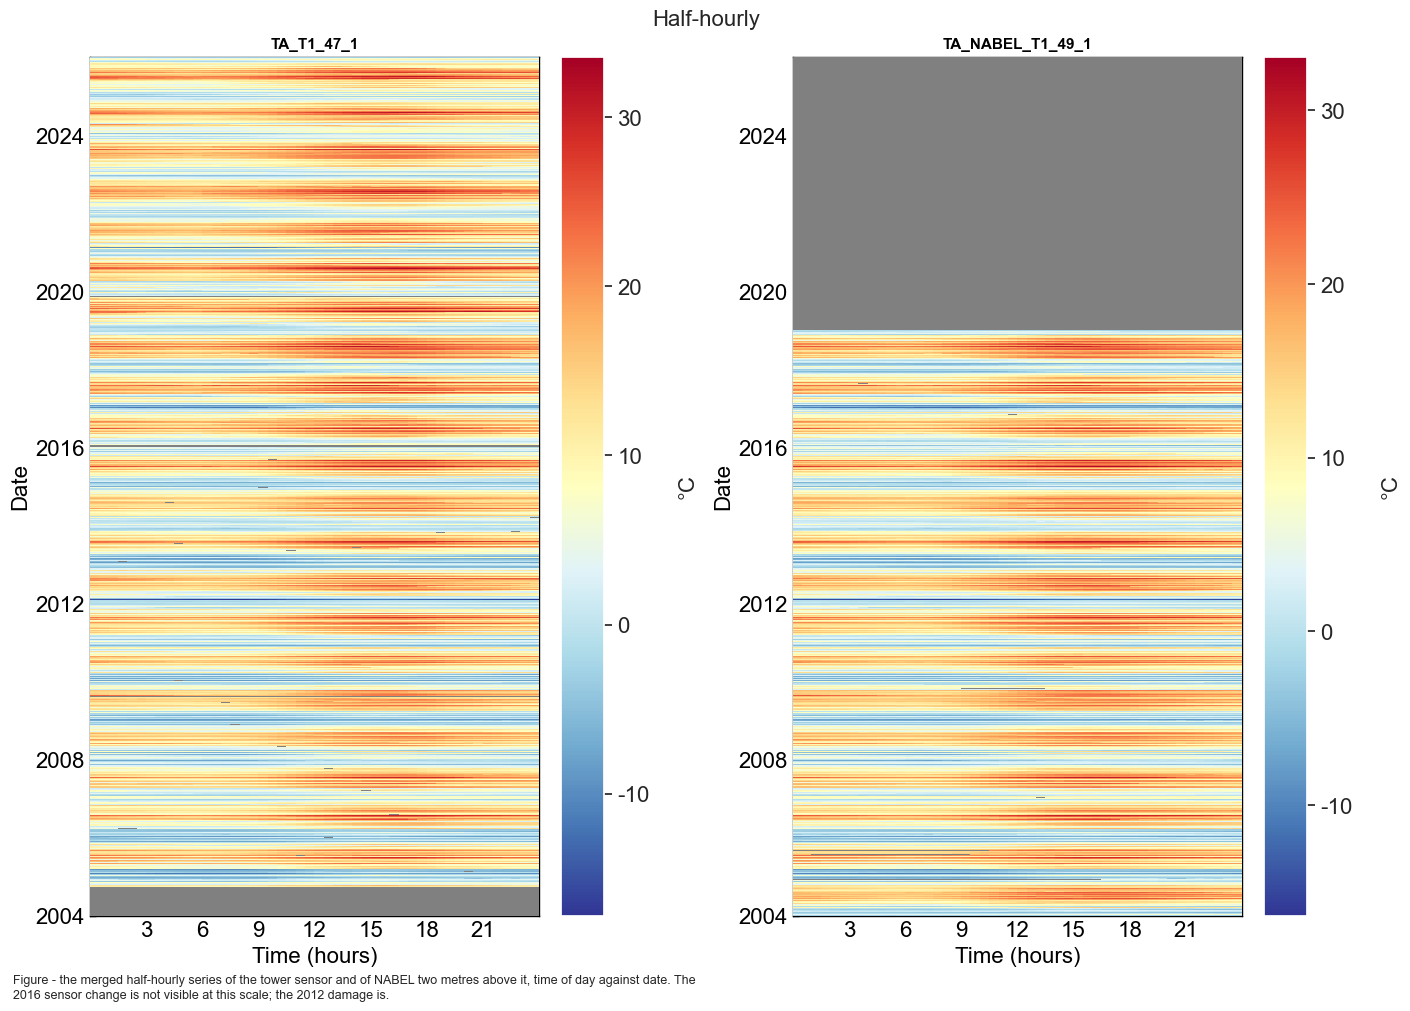

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=ta_2004_2025['TA_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='°C',
    format_style=dv.plotting.FormatStyle(title="TA_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=ta_2004_2025['TA_NABEL_T1_49_1']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='°C',
    format_style=dv.plotting.FormatStyle(title="TA_NABEL_T1_49_1", title_fontsize=11))
figcap(fig, "the merged half-hourly series of the tower sensor and of NABEL two metres above it, "
            "time of day against date. The 2016 sensor change is not visible at this scale; the "
            "2012 damage is.")

***

## ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects every variable that logger recorded, not just
radiation. The same correction as in notebook `01` is applied here to `TA_T1_47_1`. The heatmaps
below show the diurnal pattern before and after, which is the visual check that the shift is right:
after the correction the warm band has to sit around midday again.

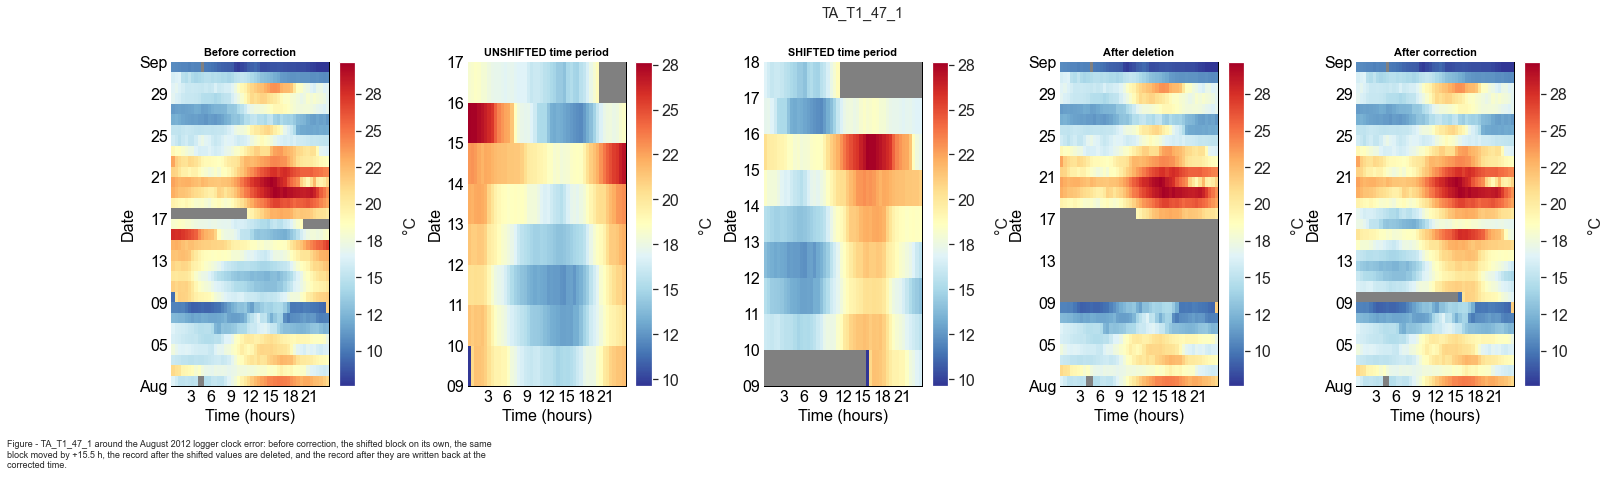

In [15]:
AFFECTED_VARS = ['TA_T1_47_1']
_df = ta_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))
    figcap(fig, f"{av} around the August 2012 logger clock error: before correction, the shifted "
                f"block on its own, the same block moved by +15.5 h, the record after the shifted "
                f"values are deleted, and the record after they are written back at the corrected "
                f"time.")

In [16]:
ta_2004_2025 = _df.copy()
ta_2004_2025

,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


### Power failure, late July to mid August 2012

The clock shift above is not the only damage in August 2012. Aligning `TA_T1_47_1` against the
NABEL sensor day by day, and searching for the lag that agrees best (baseline agreement between
the two sensors is 0.7-0.9 degC):

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-27 | 0 | 0.76 | 0.76 |
| 2012-07-30 | -24.0 h | 2.51 | 3.06 |
| 2012-08-01 | -1.0 h | 3.22 | 3.31 |
| 2012-08-06 | +1.5 h | 2.49 | 2.53 |
| 2012-08-08 | -35.5 h | 2.85 | 4.95 |
| 2012-08-09 | -33.0 h | 1.19 | 5.30 |
| **2012-08-11** | **+15.5 h** | **0.78** | 5.01 |
| **2012-08-14** | **+15.5 h** | **0.69** | 6.04 |
| **2012-08-16** | **+15.5 h** | **0.84** | 6.00 |
| 2012-08-17 | -0.5 h | 1.65 | 1.69 |
| 2012-08-18 | 0 | 0.64 | 0.64 |

- **11 to 16 August** locks onto `+15.5 h` and returns to the normal 0.7-0.8 degC agreement. That
  is the logger clock, corrected above. `SW_IN` shows the shift on the same days.
- **29 July to 9 August** stays at 1.2-3.2 degC whatever lag is applied. The apparent best lags of
  around +/-24 h are aliases, since shifting a daily cycle by about a day roughly realigns it.

The fieldbook gives the cause, and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

"could not log in the last two weeks" puts the onset around 27 July, which matches the 29 July
seen in the data. `SW_IN_T1_47_1` degrades over the same window on the same acquisition system,
consistent with a supply fault upstream of both sensors rather than with either sensor failing.

These records cannot be repaired, only removed, so they are deleted here and gap-filled afterwards
from NABEL. All windows are on the **corrected** time axis: the first runs to 10 August 15:30
because the shift moves the questionable 9 August readings forward by 15.5 h, the second covers
the transitional tail after the last shifted value, the third is the October-November period
described next. The same windows are removed in notebook `01`.

### Storm damage, late October to early November 2012

A third damaged period, found by the same day-by-day lag search:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-28 | +1.0 h | 0.89 | 0.95 |
| 2012-10-30 | +2.5 h | 2.56 | 2.66 |
| 2012-11-01 | -0.5 h | 2.89 | 2.90 |
| 2012-11-05 | -3.0 h | 5.66 | 5.88 |
| 2012-11-08 | -1.0 h | 2.25 | 2.29 |
| 2012-11-10 | 0 | 1.42 | 1.42 |

`TA` still looks normal on 28 October (0.89 degC) and only degrades from 29-30 October, whereas
`SW_IN` is already bad on the 28th. The window below starts on the 28th to match `SW_IN` and the
shared cause, which costs one good day of temperature data.

Shifting in time barely helps on any day here — where a lag does come out lowest the gain is a
few hundredths — so unlike August this is not a clock problem. The fieldbook records storm damage
and cable work in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The data return to normal from 10 November, right after that visit. Note that both entries name
the *forest floor* sensors rather than the 47 m instruments, so the link is circumstantial: what
is certain is that a storm hit the site, that cables were found stressed, and that the recovery
follows the repair visit. `SW_IN_T1_47_1` and `TA_T1_47_1` are affected together over the same
days, which again points at something shared rather than at one instrument.

The fieldbook also notes on **30.10.2012** that the MOXA was "running on wrong time base: CEST
instead of CET", fixed at 10:11 that day. Swiss daylight saving ended on 28 October, so
timestamps could have been an hour ahead for those two days — but no such offset is detectable
in the data (it would show as a best lag of -2 records, and it does not), and in any case the
whole period is removed below.

The affected records are deleted together with the August ones.

Removed 1215 degraded records from TA_T1_47_1 (gap-filled later from NABEL).


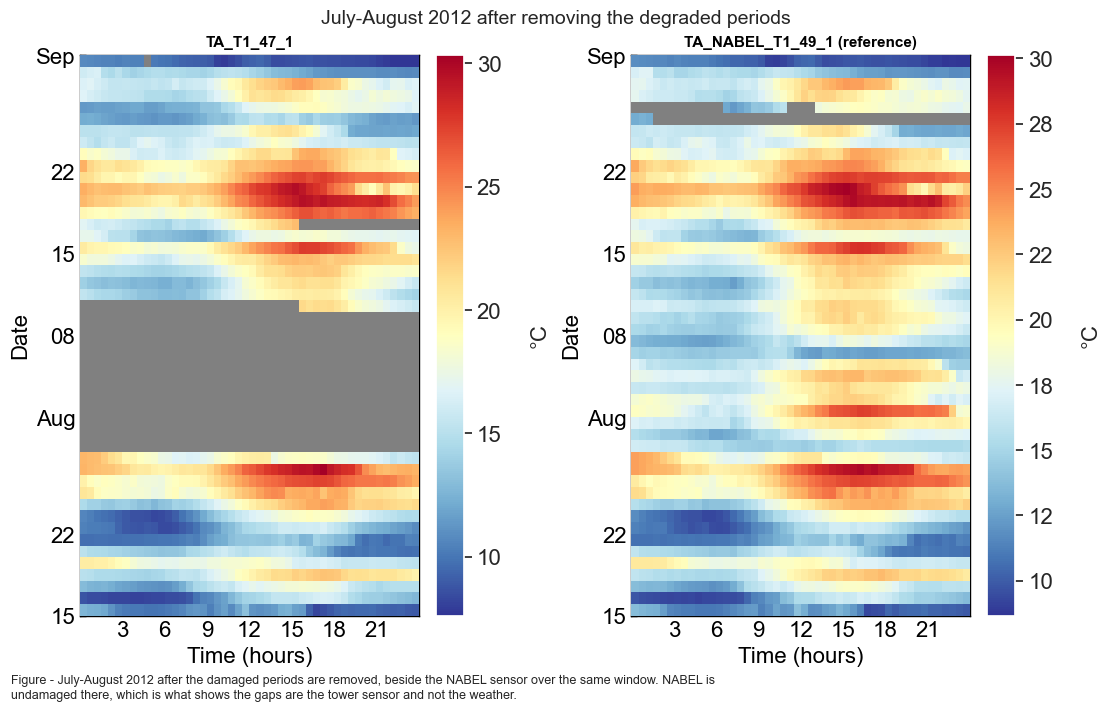

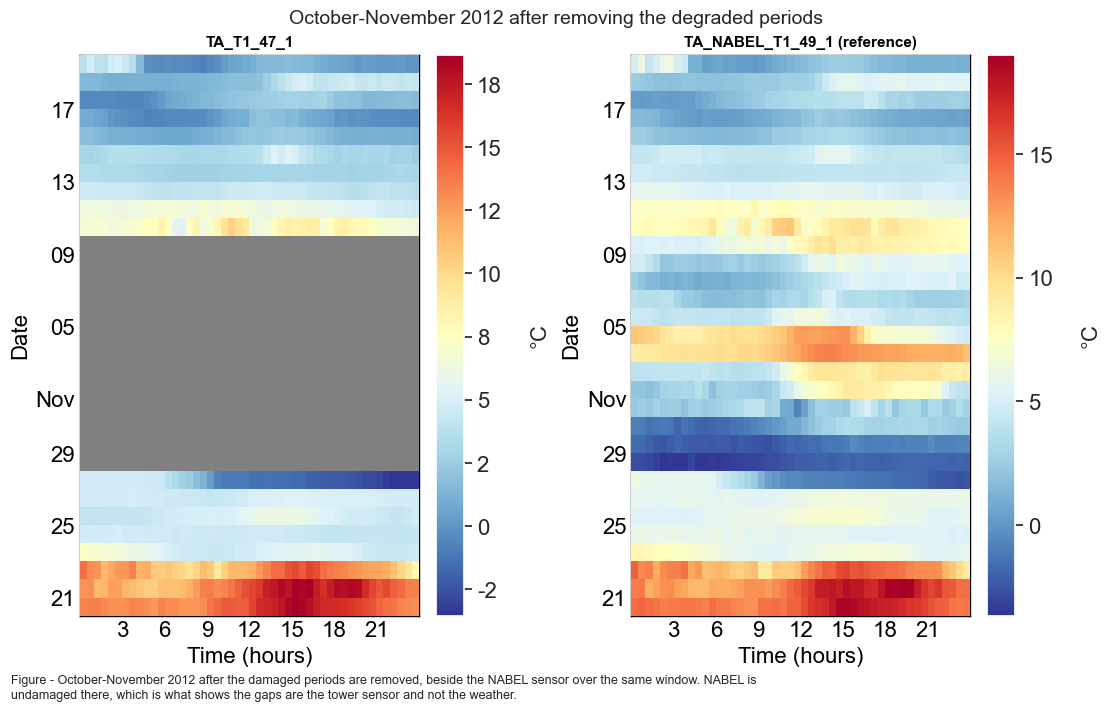

In [17]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above).
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]
DEGRADED_VAR = 'TA_T1_47_1'

_before = int(ta_2004_2025[DEGRADED_VAR].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (ta_2004_2025.index >= _start) & (ta_2004_2025.index <= _end)
    ta_2004_2025.loc[_locs, DEGRADED_VAR] = np.nan
_removed = _before - int(ta_2004_2025[DEGRADED_VAR].notna().sum())
print(f"Removed {_removed} degraded records from {DEGRADED_VAR} (gap-filled later from NABEL).")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (ta_2004_2025.index >= _lo) & (ta_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=ta_2004_2025.loc[_show, DEGRADED_VAR]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title=DEGRADED_VAR, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=ta_2004_2025.loc[_show, 'TA_NABEL_T1_49_1']).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel='°C',
        format_style=dv.plotting.FormatStyle(title='TA_NABEL_T1_49_1 (reference)', title_fontsize=11))
    figcap(fig, f"{_label} 2012 after the damaged periods are removed, beside the NABEL sensor "
                f"over the same window. NABEL is undamaged there, which is what shows the gaps are "
                f"the tower sensor and not the weather.")

::: {.callout-note title="No zero-offset correction here"}
Notebook `01` removes a nighttime zero-offset from `SW_IN`. That correction is specific to
radiation sensors, which can read a small non-zero value at night when the true value is known to
be zero. Air temperature has no such reference value, so no equivalent step exists and none is
applied.
:::

### Dataframe

In [18]:
tabcap("the merged 30MIN frame after the 2012 corrections, as it enters the break section below")
display(ta_2004_2025)
ta_2004_2025.describe()

Table - the merged 30MIN frame after the 2012 corrections, as it enters the break section below



,TA_T1_47_1,TA_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,-2.666667
2004-01-01 00:45:00,NaN,-2.566667
2004-01-01 01:15:00,NaN,-2.533333
2004-01-01 01:45:00,NaN,-2.633333
2004-01-01 02:15:00,NaN,-2.800000
...,...,...
2025-12-31 21:45:00,-3.081644,NaN
2025-12-31 22:15:00,-3.084372,NaN
2025-12-31 22:45:00,-3.423939,NaN


,TA_T1_47_1,TA_NABEL_T1_49_1
count,369065.000000,262403.000000
mean,8.954679,8.941020
std,8.163320,8.028659
min,-17.200001,-16.366667
25%,2.642000,2.633333
50%,8.870000,9.100000
75%,14.980000,14.966667
max,33.558765,33.066667


***

## 🔎 The 2016 acquisition break

On 21 January 2016 the 47 m sensor and the acquisition system were replaced together, and the
record steps by about 1.3 °C. The step is larger than the warming signal it sits inside — it
roughly doubles the difference between the 2005-2015 and 2016-2025 period means, and it doubles
the trend. Both figures are computed in *What the break does to the numbers this product is used
for* below rather than quoted here. A product that does not handle this reports an instrument
change as climate.

This section establishes six things in order, each from data or from a file on disk:

1. **that a step exists, and exactly when** — from the difference against MeteoSwiss;
2. **that this notebook does not produce it** — the corrections above and the `mst`/`diive` splice
   are both ruled out;
3. **which of the two sensors moved** — NABEL at 49 m spans the break on the same tower;
4. **which side of the break is correct** — decided at night, where a radiation-shield error
   cannot contribute;
5. **what caused it** — from the two logger programs and the fieldbook;
6. **that the error is a constant** — which is what makes a constant correction legitimate.

The correction is derived at the end from step 6, and the alternatives that were rejected are
recorded with the numbers that rejected them.

Two closing steps then deal with what a constant cannot reach. Step 9️⃣ measures the result against
**MeteoSwiss**, a reference that entered none of the derivation, separately for night and day: the
step is gone at night and survives in daylight. Step 🔟 removes what survives, by fitting each
sensor era's radiation-shield response against the aspirated NABEL sensor and standardising the
later era onto the earlier one. The exported homogenised column carries **both** terms.


### 1️⃣ A step exists, and it is not weather

MeteoSwiss Lägern is 2.5 km from the tower and is operated by a different institution, so the
difference between the two stations removes the weather and leaves the instruments. A constant
offset is expected from the elevation difference; what matters is whether that offset stays
constant.


In [19]:
# The reference is stored on TIMESTAMP_END and is shifted onto TIMESTAMP_MID, as everywhere else
# in this notebook. `ta_2004_2025` already carries the 2012 corrections, so the comparison below is
# against the series as this notebook has it, not against the raw download.
# The reference's radiation and wind columns are read here as well. Nothing in this step
# uses them; the closing step bins the residual by them, and reading them once keeps one
# reference frame in the notebook instead of two that could drift apart.
_ref = pd.read_parquet(REFPATH)[[REFCOL, REFCOL_SW, REFCOL_WS]]
_ref.index = _ref.index - pd.Timedelta(minutes=15)
_ref.index.name = ta_2004_2025.index.name

evidence = pd.concat([ta_2004_2025[['TA_T1_47_1', 'TA_NABEL_T1_49_1']], _ref], axis=1)
evidence = evidence.loc['2005':]

_res = (evidence['TA_T1_47_1'] - evidence[REFCOL]).dropna()
_yearly = _res.groupby(_res.index.year).agg(['mean', 'std', 'count'])
_yearly.columns = ['mean difference (degC)', 'SD (degC)', 'records']
_yearly.index.name = 'YEAR'
print("Tower 47 m minus MeteoSwiss Laegern, per year:")
tabcap("the difference between the tower and MeteoSwiss per year. A constant offset is expected from the elevation difference; the change between 2015 and 2016 is not")
display(_yearly.round(2))

# The step is large enough to state as a fact rather than to eyeball. Both eras are quoted on
# complete years so that a partial year cannot carry the difference.
# 2016 is left out of both periods: it is the year the changeover happened, so it belongs to
# neither era. The end year is taken from the data rather than written down.
_last = int(_res.index.year.max())
_pre = _res[(_res.index.year >= 2005) & (_res.index.year <= 2015)].mean()
_post = _res[_res.index.year >= 2017].mean()
print(f"\n2005-2015: {_pre:+.2f} degC   2017-{_last}: {_post:+.2f} degC   "
      f"step: {_post - _pre:+.2f} degC")
assert abs(_post - _pre) > 1.0, "the step is not present - has the product or the reference changed?"


Tower 47 m minus MeteoSwiss Laegern, per year:
Table - the difference between the tower and MeteoSwiss per year. A constant offset is expected from
the elevation difference; the change between 2015 and 2016 is not



,mean difference (degC),SD (degC),records
YEAR,,,
2005,-0.05,0.82,17486
2006,-0.21,1.00,17494
2007,-0.16,0.97,17507
2008,-0.10,0.81,17548
2009,-0.11,0.88,17036
2010,0.03,0.66,17351
2011,0.05,0.91,17499
2012,0.08,0.78,16286
2013,0.03,0.89,17434



2005-2015: -0.04 degC   2017-2025: +1.45 degC   step: +1.50 degC


### 2️⃣ The step is not produced in this notebook

Two candidates inside this notebook are ruled out before looking at the instruments.

**The corrections above.** They act on August, October and November 2012 only. Nothing in this
notebook touches 2015 or 2016.

**The `mst`/`diive` splice.** `TA_T1_47_1` is screened by the MeteoScreeningTool until the end of
2021 and by diive afterwards, so both sides of a 2016 break are the *same* screening. The merge
cell above reports how many records each source contributed; the check below confirms that the
`diive` record does not reach back to 2016 and therefore cannot have introduced the step.

The database tags agree: the `mst` series carries one `raw_varname` (`TA_AVG_T1_47_1`), `gain 1.0`
and `offset 0.0` across its whole extent, so nothing was rescaled on the way in either.


In [20]:
# The mst/diive boundary sits at the end of 2021, nowhere near the break. If the diive record began
# in 2016 this whole diagnosis would be a screening artefact instead of an instrument change.
_diive_first = nabel_eth_diive_ta['TA_T1_47_1'].dropna()
_diive_first = _diive_first.index[0] if len(_diive_first) else None
print(f"first diive-screened TA_T1_47_1 record: {_diive_first}")
assert _diive_first is None or _diive_first.year >= 2021, (
    "the diive screening reaches back to the break - the step could be a screening artefact")

# And this notebook's own corrections are confined to 2012.
print("2012 removal windows applied above:")
for _start, _end in BAD_WINDOWS_2012:
    print(f"  {_start} -> {_end}")
assert all(pd.Timestamp(_s).year == 2012 for _s, _e in BAD_WINDOWS_2012), \
    "a correction window outside 2012 - the reasoning below no longer holds"


first diive-screened TA_T1_47_1 record: 2022-01-01 00:15:00
2012 removal windows applied above:
  2012-07-29 00:00 -> 2012-08-10 15:30
  2012-08-17 15:30 -> 2012-08-18 00:00
  2012-10-28 00:00 -> 2012-11-10 00:00


### 3️⃣ The tower sensor moved, not the references

NABEL sits at 49 m on the **same tower**, two metres above the ETH sensor, and runs to the end of
2018. It therefore brackets the break with an independent measurement of the same air. Together
with MeteoSwiss this gives three pairwise differences, and only one of them can step without
implicating the tower sensor.

If `NABEL - MeteoSwiss` is flat across the break, the two references agree with each other and the
change is at the ETH sensor. If it steps, the diagnosis would have to be re-opened.


In [21]:
# Three pairwise differences across the break. Complete years either side, so that the January
# 2016 outage does not sit inside a compared window.
_pairs = [('tower 47 m - NABEL 49 m', 'TA_T1_47_1', 'TA_NABEL_T1_49_1'),
          ('tower 47 m - MeteoSwiss ', 'TA_T1_47_1', REFCOL),
          ('NABEL 49 m - MeteoSwiss ', 'TA_NABEL_T1_49_1', REFCOL)]

# Named once, because the figure below marks the same boundary the table compares across. The
# window ends in 2018 because NABEL does; the break year is inside the later window rather than
# excluded, which is only sound because it holds no measurement before the changeover.
PAIR_WIN_PRE = (2013, 2015)
PAIR_WIN_POST = (2016, 2018)

_rows = []
for _label, _a, _b in _pairs:
    _d = (evidence[_a] - evidence[_b]).dropna()
    _p = _d[(_d.index.year >= PAIR_WIN_PRE[0]) & (_d.index.year <= PAIR_WIN_PRE[1])]
    _q = _d[(_d.index.year >= PAIR_WIN_POST[0]) & (_d.index.year <= PAIR_WIN_POST[1])]
    _rows.append({'pair': _label,
                  f'{PAIR_WIN_PRE[0]}-{PAIR_WIN_PRE[1]} (degC)': _p.mean(),
                  f'{PAIR_WIN_POST[0]}-{PAIR_WIN_POST[1]} (degC)': _q.mean(),
                  'step (degC)': _q.mean() - _p.mean(), 'records': len(_p) + len(_q)})
_step_table = pd.DataFrame(_rows).set_index('pair')
tabcap("the three pairwise differences across the break. Only the two involving the tower step, which is what attributes the change to the tower sensor")
display(_step_table.round(2))

# The decisive assertion of this section: the two references agree with each other across the
# break. Without this, the step could belong to either station.
_ref_step = abs(_step_table.loc['NABEL 49 m - MeteoSwiss ', 'step (degC)'])
print(f"NABEL against MeteoSwiss changes by {_ref_step:.2f} degC across the break.")
assert _ref_step < 0.25, (
    "the two references disagree across the break - the step cannot be attributed to the tower "
    "sensor without further evidence")


Table - the three pairwise differences across the break. Only the two involving the tower step,
which is what attributes the change to the tower sensor



,2013-2015 (degC),2016-2018 (degC),step (degC),records
pair,,,,
tower 47 m - NABEL 49 m,-1.05,0.55,1.60,104036
tower 47 m - MeteoSwiss,-0.01,1.53,1.54,104023
NABEL 49 m - MeteoSwiss,1.04,0.99,-0.06,105112


NABEL against MeteoSwiss changes by 0.06 degC across the break.


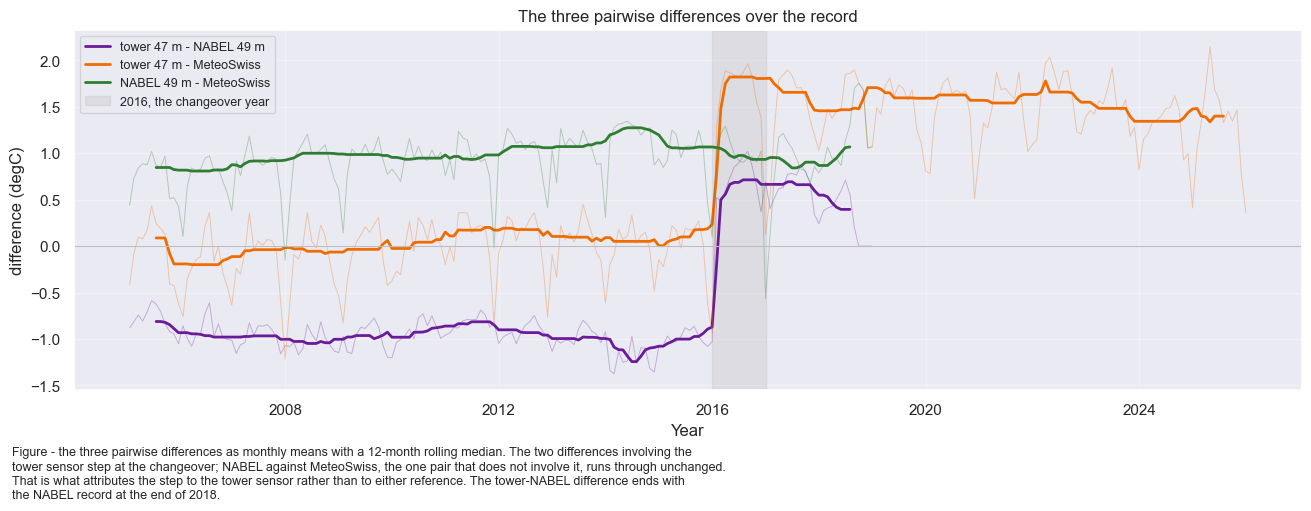

In [22]:
# The same three differences over the whole record, as monthly means with a 12-month rolling
# median over them. The table above is two windows of this figure; the figure shows whether the
# step is a step or the end of a drift, which two window means cannot.
fig, ax = plt.subplots(figsize=(13, 5), dpi=100, layout="constrained")
for (_label, _a, _b), _colour in zip(_pairs, ['#6A1B9A', '#EF6C00', '#2E7D32']):
    _d = (evidence[_a] - evidence[_b]).dropna().resample('ME').mean()
    ax.plot(_d.index, _d, color=_colour, lw=0.7, alpha=0.3)
    ax.plot(_d.index, _d.rolling(12, center=True).median(), color=_colour, lw=2, label=_label.strip())
ax.axvspan(pd.Timestamp(f'{PAIR_WIN_POST[0]}-01-01'), pd.Timestamp(f'{PAIR_WIN_POST[0] + 1}-01-01'),
           color='#9E9E9E', alpha=0.18, label=f'{PAIR_WIN_POST[0]}, the changeover year')
ax.axhline(0, color='#BDBDBD', lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("difference (degC)")
ax.set_title("The three pairwise differences over the record")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
figcap(fig, "the three pairwise differences as monthly means with a 12-month rolling median. The "
            "two differences involving the tower sensor step at the changeover; NABEL against "
            "MeteoSwiss, the one pair that does not involve it, runs through unchanged. That is "
            "what attributes the step to the tower sensor rather than to either reference. The "
            "tower-NABEL difference ends with the NABEL record at the end of 2018.")

### 4️⃣ Exactly when, and which side is correct

The changeover sits inside an outage, so the break can be dated to the record rather than to a
date someone wrote down.

Which side is *correct* is decided **at night**. A radiation-shield error needs sunlight, so at
night two air-temperature sensors two metres apart on one tower should agree to a few tenths.
Night is taken from potential radiation computed from the site coordinates, so the test depends on
no external measurement at all.


In [23]:
# The outage that contains the changeover, located in the data.
_meas = ta_2004_2025['TA_T1_47_1'].loc['2015-12-01':'2016-03-01']
_missing = _meas.isna()
_blocks = _missing.ne(_missing.shift()).cumsum()
_runs = _missing[_missing].groupby(_blocks[_missing])
_longest = max(_runs, key=lambda kv: len(kv[1]))[1]

# The two boundaries are read off that outage rather than off a date written here. A hard-coded
# '2016-01-01' would also slice inclusively on both sides (pandas partial-string indexing), so a
# measurement on that day could put LAST_BEFORE after BREAK without anything complaining.
_series = ta_2004_2025['TA_T1_47_1'].dropna()
LAST_BEFORE = _series[_series.index < _longest.index[0]].index[-1]
BREAK = _series[_series.index > _longest.index[-1]].index[0]
print(f"outage:               {_longest.index[0]} -> {_longest.index[-1]} "
      f"({len(_longest)} records, {len(_longest) * 0.5:.0f} h)")
print(f"last measured before: {LAST_BEFORE}")
print(f"first measured after: {BREAK}   <- BREAK")
assert len(_longest) > 500, "the January 2016 outage is not in the data as expected"
assert LAST_BEFORE < _longest.index[0] <= _longest.index[-1] < BREAK, \
    "the break boundaries do not bracket the outage"

# The first tower measurement of all. Everything before it is modelled throughout.
RECORD_START = _series.index[0]
print(f"tower record begins:  {RECORD_START}  "
      f"({(RECORD_START - ta_2004_2025.index[0]).days} days after the product starts)")

# Night from potential radiation: no reference measurement enters this test. It is computed over
# the WHOLE record, not over the evidence window below - the checks at export use this mask, and
# one restricted to 2005 onwards would silently skip 2004, which is the least constrained year.
_potrad = dv.variables.potrad(timestamp_index=ta_2004_2025.index, lat=SITE_LAT, lon=SITE_LON,
                              utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
NIGHT = _potrad <= 0

_night = evidence[['TA_T1_47_1', 'TA_NABEL_T1_49_1']].dropna()
_night = _night[NIGHT.reindex(_night.index).fillna(False)]
_era_pre = _night.loc[:LAST_BEFORE]
_era_post = _night.loc[BREAK:'2018']

for _label, _era in [('MP101A era (2005 - 2015)', _era_pre), ('CS215 era  (2016 - 2018)', _era_post)]:
    _bias = _era['TA_T1_47_1'] - _era['TA_NABEL_T1_49_1']
    print(f"  {_label}: tower minus NABEL at night = {_bias.mean():+.2f} degC "
          f"(SD {_bias.std():.2f}, n={len(_era):,})")


outage:               2016-01-01 00:15:00 -> 2016-01-21 13:45:00 (988 records, 494 h)
last measured before: 2015-12-31 23:45:00
first measured after: 2016-01-21 14:15:00   <- BREAK
tower record begins:  2004-09-20 10:45:00  (263 days after the product starts)


  MP101A era (2005 - 2015): tower minus NABEL at night = -1.09 degC (SD 0.25, n=90,942)
  CS215 era  (2016 - 2018): tower minus NABEL at night = +0.25 degC (SD 0.25, n=24,513)


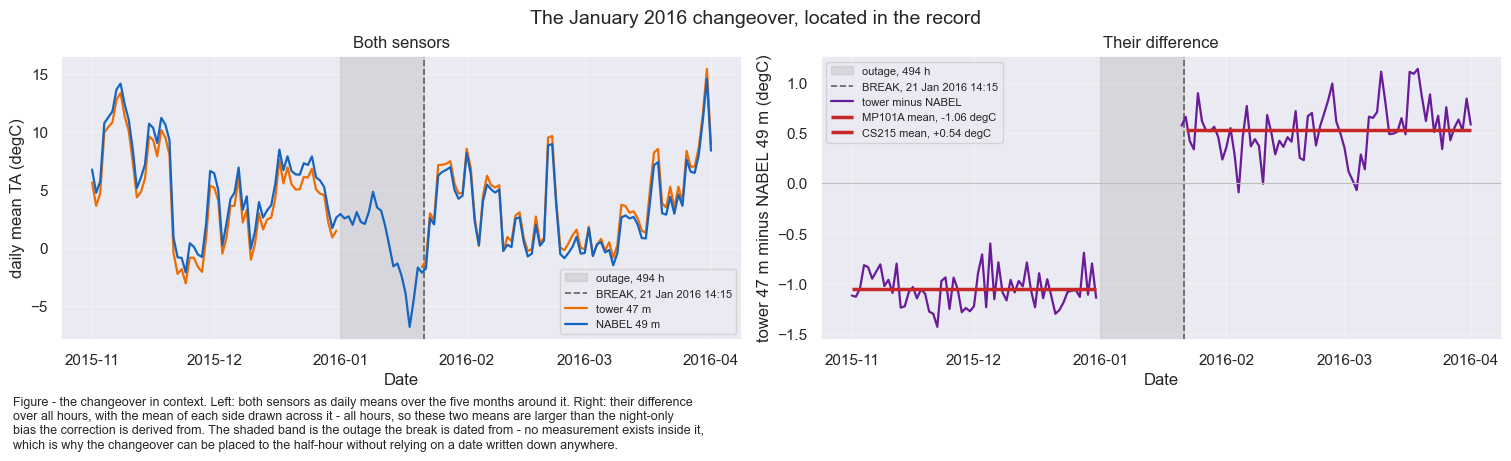

In [24]:
# The outage located above, drawn with the sensor it is dated against. Left: both series as daily
# means over the three months around it. Right: their difference, which is where the change is -
# the two eras sit on visibly different levels either side of a gap that contains no measurement.
_zoom_from, _zoom_to = '2015-11-01', '2016-04-01'
_zoom = ta_2004_2025.loc[_zoom_from:_zoom_to, ['TA_T1_47_1', 'TA_NABEL_T1_49_1']]
_zoom_daily = _zoom.resample('D').mean()
_zoom_diff = (_zoom['TA_T1_47_1'] - _zoom['TA_NABEL_T1_49_1']).resample('D').mean()

fig, axs = plt.subplots(ncols=2, figsize=(15, 4.5), dpi=100, layout="constrained")
fig.suptitle("The January 2016 changeover, located in the record", fontsize=14)

for _ax in axs:
    _ax.axvspan(_longest.index[0], _longest.index[-1], color='#9E9E9E', alpha=0.25,
                label=f"outage, {len(_longest) * 0.5:.0f} h")
    _ax.axvline(BREAK, color='#616161', lw=1.2, ls='--', label=f"BREAK, {BREAK:%d %b %Y %H:%M}")
    _ax.set_xlabel("Date")
    _ax.grid(alpha=0.3)

axs[0].plot(_zoom_daily.index, _zoom_daily['TA_T1_47_1'], color='#EF6C00', lw=1.6,
            label='tower 47 m')
axs[0].plot(_zoom_daily.index, _zoom_daily['TA_NABEL_T1_49_1'], color='#1565C0', lw=1.6,
            label='NABEL 49 m')
axs[0].set_ylabel("daily mean TA (degC)")
axs[0].set_title("Both sensors")
axs[0].legend(fontsize=8)

axs[1].plot(_zoom_diff.index, _zoom_diff, color='#6A1B9A', lw=1.6, label='tower minus NABEL')
axs[1].axhline(0, color='#BDBDBD', lw=0.8)
for _side, _label in [(slice(_zoom_from, LAST_BEFORE), 'MP101A'), (slice(BREAK, _zoom_to), 'CS215')]:
    _m = _zoom_diff.loc[_side].mean()
    axs[1].hlines(_m, *[_zoom_diff.loc[_side].index[i] for i in (0, -1)], color='#C62828', lw=2.5,
                  label=f"{_label} mean, {_m:+.2f} degC")
axs[1].set_ylabel("tower 47 m minus NABEL 49 m (degC)")
axs[1].set_title("Their difference")
axs[1].legend(fontsize=8)
figcap(fig, "the changeover in context. Left: both sensors as daily means over the five months "
            "around it. Right: their difference over all hours, with the mean of each side drawn "
            "across it - all hours, so these two means are larger than the night-only bias the "
            "correction is derived from. The "
            "shaded band is the outage the break is dated from - no measurement exists inside it, "
            "which is why the changeover can be placed to the half-hour without relying on a date "
            "written down anywhere.")

The earlier era reads about 1.1 °C below a sensor two metres above it, for eleven years. The
later era agrees with the same sensor to about a quarter of a degree, which is inside the
manufacturer's specification for it. **The pre-2016 era is the one in error.**

That is the opposite of what the shape of the series suggests: the record jumps *upwards* in 2016,
so the natural reading is that the later years are too warm. They are not — the earlier years are
too cold.


### 5️⃣ What caused it: the two logger programs

Both programs are on disk and are read here rather than quoted. Only the measurement instruction
is extracted: these files are signed by their authors, and a notebook output is published like any
other page, so the header is never printed and everything that is printed passes through the same
redaction used for the fieldbook.


In [25]:
# --- Fieldbook and logger-script redaction ----------------------------------------------------
# Both the GIN export and the logger programs name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebook 08; it lives beside the export, OUTSIDE this
# repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')
def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the
    second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4,
                    expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as 'the program does not measure this', and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support. The CR10X
    program refers to its air-temperature location four times - once to measure it, once per
    heating threshold, and once to average it into the output table.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


In [26]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so both
# failure paths are exercised before anything is read.
try:
    program_excerpt(PROGRAM_AFTER, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")


OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, the unknown-name net fired on a name that is not in the map


In [27]:
# The pre-2016 measurement, from the CR10X program of the old acquisition. Anchored on the sensor
# comment rather than on the storage location, because the program refers to that location four
# times and only one of them is the measurement.
print("=" * 78)
print(f"BEFORE: {Path(PROGRAM_BEFORE).name}")
print("=" * 78)
_excerpt_before = program_excerpt(PROGRAM_BEFORE, r'Rotronic MP101A', before=1, after=12)
print(_excerpt_before)

# The post-2016 measurement, from the CR1000 program installed at the changeover.
print("\n" + "=" * 78)
print(f"AFTER:  {Path(PROGRAM_AFTER).name}")
print("=" * 78)
_excerpt_after = program_excerpt(PROGRAM_AFTER, r'CS215', before=1, after=2)
print(_excerpt_after)

# These files are signed by their authors too, so they get the same two nets as the fieldbook:
# redaction inside program_excerpt, and the unknown-name audit here.
audit_unmapped_names([_excerpt_before, _excerpt_after], 'logger programs')

BEFORE: LAEGEREN.20060524.csi
;--------------------------------------------------------
; Rotronic MP101A temperature and relative humidity probe
;--------------------------------------------------------


14:  Volt (SE) (P1)
 1: 1        Reps
 2: 35       2500 mV 50 Hz Rejection Range
 3: 4        SE Channel
 4: 18       Loc [ Temp_air  ]
 5: 0.1      Mult
 6: 0        Offset



AFTER:  CH-LAE_iDL_T1_47_1.CR1
		PortSet(1,0)
		'C'CS215 Temperature & Relative Humidity Sensor measurements 'TA_T1_47_1' and 'RH_T1_47_1'
		SDI12Recorder(TARH_T1_47_1(),3,"0","M!",1,0)
		
  logger programs: no unmapped name-shaped tokens (54 allowlisted terms)


0

The two instructions say what changed.

**Before**, a **Rotronic MP101A** read as a single-ended voltage with `Mult 0.1` and `Offset 0`:
ten millivolts per degree, with zero volts taken as zero degrees. The same instruction, on the same
channel, with the same constants, appears in every tower program version from 26 May 2004 to
24 May 2006 — and the yearly differences in step 1 show the constants did not change afterwards
either.

**After**, a **Campbell CS215** read over SDI-12 with multiplier `1` and offset `0`. The value
arrives from the sensor already in degrees; the logger applies no scaling at all, so a mistaken
multiplier in the new program cannot be the cause.

The `Mult 0.1` of the old instruction is what makes the error interpretable: in that measurement
chain, **one degree in the record is ten millivolts at the logger input**.


### 6️⃣ The fieldbook: the changeover is documented to the day

The maintenance record is read and filtered here rather than quoted, so a newer export re-derives
this instead of leaving a stale copy in the prose. The filter is deliberately wide: entries that
explain a fault at this site are routinely filed under a different device, and the decisive ones
here carry no device tag at all.


In [28]:
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')

# The window from the last measurement before the outage to a fortnight after the record resumes.
# Rows dated exactly 2016-01-01 are dropped: that date is a backdated GIN inventory import of the
# whole site, not a set of events, and it would bury the entries that matter.
_win = fb[(fb['Date'] >= '2016-01-02') & (fb['Date'] <= '2016-02-14')]
_win = _win[_win['text'].str.len() > 40].sort_values('Date')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")
print(f"entries between 02 Jan and 14 Feb 2016: {len(_win)}\n")
assert len(_win) > 0, "no fieldbook entries in the changeover window - is this the right export?"

# Only the entries that name the tower logger, its program or the new tower box.
_rx = r'logger|loggerprogram|CR1000|towerbox|tower box|wall mounting|iDL_T1_47|T1_47'
for _, _r in _win[_win['text'].str.contains(_rx, case=False, regex=True)].iterrows():
    print(f"--- {_r['Date'].date()}")
    print(f"    {_r['text'][:600]}\n")


  fieldbook entries: no unmapped name-shaped tokens (54 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17
entries between 02 Jan and 14 Feb 2016: 19

--- 2016-01-08
    08.01.2016 (person 14, person 01) starting 0930 the eddy boom was retracted for installation work Installed the 7200 including the analyzer and flow module box. Attached the necessary mountings to the boom the tower handrails replaced the broken vektor instruments A100L cup anemometer with a new vector instruments A100LK cup anemometer wwith SN 16697 installed a new direct Kipp&Zonen par ( SN:) sensor and replaced the reflective par ( SN:) on the boom with the Kipp&Zonen par ( SN:) installed the new towerbox and connected the ethernet and 24V power cable to the box tested unispec –> ok tested 

--- 2016-01-21
    Added new device. When installing the new wall installation in the hut including power supply, logger, ioLogik and more

--- 2016-01-21
    21.01.2016 (person 05 remote) Calibrated LI-7000 0

Three entries bracket the outage: a new tower box with its own 24 V supply on 8 January, the hut
and profile loggers shut down and remounted on 21 January, and on 10 February the re-upload of the
logger program **`CH-LAE_CR1000_T1_47_1-20160118.CR1`** — dated 18 January, inside the outage —
together with the registration of `CR1000_E5522` at the tower top.

Two independent confirmations sit in the database rather than in the fieldbook: the panel
temperature of that logger (`T_CR1000_AVG_T1_47_1`) and the profile channel `TA_PRF_T1_54_1` both
have their **first record ever** at the moment the tower record resumes.

What the fieldbook does **not** contain is a replacement of the air-temperature sensor itself. GIN
never registers a temperature or humidity device at `CH-LAE_T1_47`, before or after — the sensor
identity exists only in the two logger programs read above. The fieldbook dates the changeover; it
does not describe it.


### 7️⃣ The error is a constant, so a constant corrects it

A single offset is only legitimate if the error is a single offset. In the old measurement chain
the record is a voltage scaled by `Mult 0.1`, so the two candidates are distinguishable:

- a **zero-point error** — a constant voltage added to the input — gives a bias that is constant
  in degrees Celsius across the temperature range;
- a **span or gain error** gives one that grows with temperature.

The night bias against NABEL is binned by air temperature below. A flat profile is a zero-point
error; a sloped one would rule a constant correction out.


In [29]:
# Night bias against NABEL, binned by air temperature, per era.
_bins = [(-20, -5), (-5, 0), (0, 5), (5, 10), (10, 15), (15, 20), (20, 35)]
_rows = []
for _lo, _hi in _bins:
    _row = {'TA bin (degC)': f"{_lo} to {_hi}"}
    for _label, _era in [('MP101A era', _era_pre), ('CS215 era', _era_post)]:
        _s = _era[(_era['TA_NABEL_T1_49_1'] > _lo) & (_era['TA_NABEL_T1_49_1'] <= _hi)]
        _row[_label] = (_s['TA_T1_47_1'] - _s['TA_NABEL_T1_49_1']).mean() if len(_s) > 200 else np.nan
        _row[f'n ({_label})'] = len(_s)
    _rows.append(_row)
_bias_profile = pd.DataFrame(_rows).set_index('TA bin (degC)')
tabcap("the night bias against NABEL binned by air temperature, per era. A flat profile is a zero-point error; a sloped one would rule a constant correction out")
display(_bias_profile.round(2))

# Fitted per era: the intercept is the bias at 0 degC, the slope is the temperature dependence.
_fits = {}
for _label, _era in [('MP101A era', _era_pre), ('CS215 era', _era_post)]:
    _bias = _era['TA_T1_47_1'] - _era['TA_NABEL_T1_49_1']
    _slope, _intercept = np.polyfit(_era['TA_NABEL_T1_49_1'].to_numpy(), _bias.to_numpy(), 1)
    _fits[_label] = (_slope, _intercept)
    print(f"  {_label}: bias = {_slope:+.5f} * TA {_intercept:+.4f} degC   "
          f"(implied input error at 0 degC: {_intercept * 10:+.1f} mV at Mult 0.1)")

# A slope of 0.007 degC per degC is 0.3 degC over the full 40 degC range of this record, against a
# constant of about 1.3 degC. The error is overwhelmingly a zero-point offset.
assert abs(_fits['MP101A era'][0]) < 0.02, (
    "the pre-2016 bias depends on temperature more strongly than a zero-point error allows - "
    "a constant offset is not the right correction")


Table - the night bias against NABEL binned by air temperature, per era. A flat profile is a zero-
point error; a sloped one would rule a constant correction out



,MP101A era,n (MP101A era),CS215 era,n (CS215 era)
TA bin (degC),,,,
-20 to -5,-1.01,4399,0.21,639
-5 to 0,-1.09,13131,0.16,3596
0 to 5,-1.17,20565,0.18,5798
5 to 10,-1.18,19215,0.25,4997
10 to 15,-1.06,19097,0.30,4309
15 to 20,-0.95,10811,0.32,3538
20 to 35,-0.86,3724,0.36,1636


  MP101A era: bias = +0.00690 * TA -1.1396 degC   (implied input error at 0 degC: -11.4 mV at Mult 0.1)
  CS215 era: bias = +0.00837 * TA +0.1801 degC   (implied input error at 0 degC: +1.8 mV at Mult 0.1)


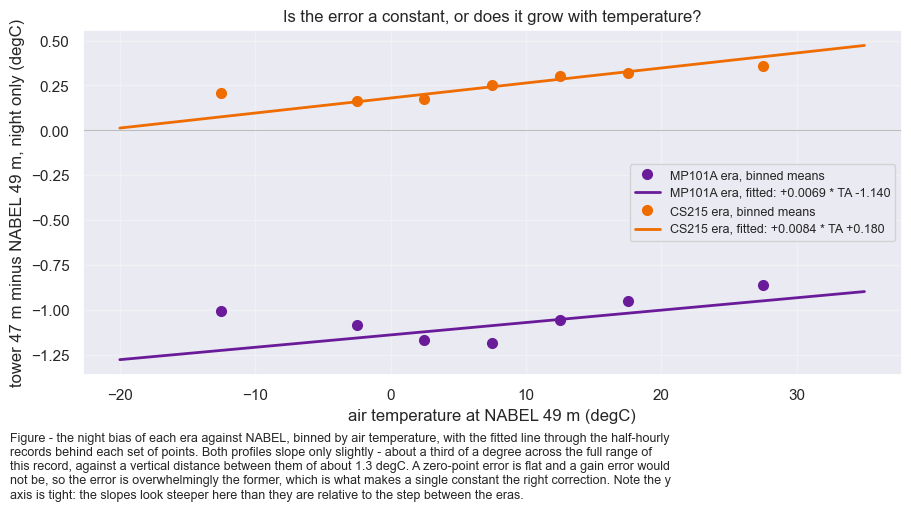

In [30]:
# The table above, drawn, with the fitted lines through it. A zero-point error is a horizontal
# line; a gain error would slope. The fits are over the half-hourly records, not over the bins,
# so the lines are not fits to the points drawn here - the points are there to show the scatter
# the line was taken through.
fig, ax = plt.subplots(figsize=(9, 5), dpi=100, layout="constrained")
_centres = np.array([(_lo + _hi) / 2 for _lo, _hi in _bins])
_grid = np.linspace(min(_lo for _lo, _hi in _bins), max(_hi for _lo, _hi in _bins), 100)
for _label, _colour in [('MP101A era', '#6A1B9A'), ('CS215 era', '#EF6C00')]:
    ax.plot(_centres, _bias_profile[_label].to_numpy(), 'o', color=_colour, ms=7,
            label=f"{_label}, binned means")
    _slope, _intercept = _fits[_label]
    ax.plot(_grid, _slope * _grid + _intercept, '-', color=_colour, lw=2,
            label=f"{_label}, fitted: {_slope:+.4f} * TA {_intercept:+.3f}")
ax.axhline(0, color='#BDBDBD', lw=0.8)
ax.set_xlabel("air temperature at NABEL 49 m (degC)")
ax.set_ylabel("tower 47 m minus NABEL 49 m, night only (degC)")
ax.set_title("Is the error a constant, or does it grow with temperature?")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
figcap(fig, "the night bias of each era against NABEL, binned by air temperature, with the fitted "
            "line through the half-hourly records behind each set of points. Both profiles slope "
            "only slightly - about a third of a degree across the full range of this record, "
            "against a vertical distance between them of about 1.3 degC. A zero-point error is "
            "flat and a gain error would not be, so the error is overwhelmingly the former, which "
            "is what makes a single constant the right correction. Note the y axis is tight: the "
            "slopes look steeper here than they are relative to the step between the eras.")

The profile is flat. Fitted, the pre-2016 bias carries a slope of about `+0.007` °C per °C —
0.3 °C across the full 40 °C range of this record, against a constant of about 1.3 °C. It is a
zero-point error, and at `Mult 0.1` its size at the logger input is about **−11 mV**.

An error of that size and character has an ordinary explanation in that measurement chain: a
single-ended analog channel referenced to logger ground, fed by a cable running down from 47 m. A
ground-potential difference of a few millivolts, or a zero-trim error in the probe's own output,
produces exactly this — a constant voltage, independent of temperature, of stratification and of
wind, and immune to nothing except the removal of the analog path. Which is what happened in 2016,
when the CS215 made the signal digital and the offset disappeared.

The evidence does not separate those two causes, and the probe's configuration sheet would be
needed to do so. It does establish the class of error, which is what the correction depends on.


### 8️⃣ The correction

The homogenised column raises the pre-2016 era onto the level of the post-2016 era — the same
direction as the `_HOMOGENIZED` column of notebook `08`, and for the same reason: the later era is
the one that agrees with the reference.

The constant is the **difference of the two fitted intercepts**, that is, the step between the
eras at 0 °C. It is preferred over the plain difference of the night means (they differ by less
than 0.02 °C here) because the intercept removes the small residual temperature dependence
measured above.

The measured column is left as measured. Nothing is rescaled in place.


In [31]:
# The homogenisation constant, derived from the fits above rather than written down.
OFFSET = _fits['CS215 era'][1] - _fits['MP101A era'][1]
print(f"Homogenisation offset for the pre-{BREAK.year} era: {OFFSET:+.4f} degC")
print(f"  (CS215 intercept {_fits['CS215 era'][1]:+.4f} minus "
      f"MP101A intercept {_fits['MP101A era'][1]:+.4f})")

# A guard on the derived constant. If a future re-run produces something far from the measured
# step, the fit has gone wrong and the correction must not be applied silently.
assert 1.0 < OFFSET < 1.6, f"the derived offset {OFFSET:.3f} degC is outside the expected range"

# The source flag, on the full product index. Two codes mark records no sensor produced: the
# outage that contains the changeover, and the months before the record begins.
source_flag = pd.Series(SOURCE_CS215, index=ta_2004_2025.index, name='FLAG_TA_T1_47_1_SOURCE')
source_flag[source_flag.index <= LAST_BEFORE] = SOURCE_MP101A
source_flag[(source_flag.index > LAST_BEFORE) & (source_flag.index < BREAK)] = SOURCE_CHANGEOVER
source_flag[source_flag.index < RECORD_START] = SOURCE_PRERECORD

print("\nSource flag:")
_counts = source_flag.value_counts().sort_index()
tabcap("how many records each acquisition era accounts for. Codes 2 and 3 mark records that no sensor produced")
display(pd.DataFrame({'records': _counts,
                      'meaning': [FLAG_SOURCE_LEGEND[i] for i in _counts.index]}))
assert source_flag.isin(FLAG_SOURCE_LEGEND).all(), "unknown code in the source flag"
assert (source_flag == SOURCE_CHANGEOVER).sum() == len(_longest), \
    "the changeover code does not cover exactly the outage that contains the break"
assert (source_flag == SOURCE_PRERECORD).sum() == (ta_2004_2025.index < RECORD_START).sum(), \
    "the pre-record code does not cover exactly the period before the first measurement"


Homogenisation offset for the pre-2016 era: +1.3197 degC
  (CS215 intercept +0.1801 minus MP101A intercept -1.1396)

Source flag:
Table - how many records each acquisition era accounts for. Codes 2 and 3 mark records that no
sensor produced



,records,meaning
FLAG_TA_T1_47_1_SOURCE,,
0,174356,"0 = Campbell CS215, SDI-12, 21 Jan 2016 onward..."
1,197739,"1 = Rotronic MP101A, analog single-ended, 2004..."
2,988,"2 = acquisition changeover, 01 - 21 Jan 2016: ..."
3,12645,3 = before the tower record begins (2004): no ...


#### What was rejected, and the numbers that rejected it

**Substituting NABEL 49 m for the early years.** NABEL is the better instrument — aspirated,
maintained by a monitoring network, and 99.7 % present in 2004 where the tower record is only 28 %
complete. It nevertheless makes the *series* less homogeneous, which is what this column is for:
splicing an aspirated sensor to a passively shielded one places the whole shield difference at the
join, and the join simply moves from January 2016 to the end of the NABEL record. Scored against
MeteoSwiss in `TA_HOMOGENIZATION_OPTIONS.ipynb`, the daytime step it creates in 2019 is larger than
the one it removes in 2016. Substituting a different institution's instrument into a column named
`TA_T1_47_1` would also make the name false for fourteen of twenty-one years, and NABEL stops at
the end of 2018, so the construction could never cover the record.

**Putting the whole record on the aspirated scale.** Subtracting each era's *entire* response
against NABEL, rather than only the difference between the two responses, scores better on every
criterion — the residual step, its radiation profile and the scatter against MeteoSwiss. It is not
adopted because it rescales all twenty-one years onto another institution's instrument: the column
would no longer be what the 47 m sensor reported, corrected, but an estimate of what an aspirated
sensor at 47 m would have reported. That is a different product, and the choice is recorded rather
than taken silently.

**Leaving the shield difference in place.** This is what version 6 of this notebook did, and the
three grounds it gave — that the CS215 response can only be fitted on the three years NABEL
overlaps it and would be applied over ten; that those ten years contain a screen wiring fault
recorded in June 2022 and a shelter destroyed and replaced in late 2025; and that it would rest on
a gap-filled radiation driver — were **tested** in the companion notebook and none of them held.
The three-year fit places the extrapolated years on the earlier era's own level, the two site
events move the corrected and the uncorrected series by the same amount, and refitting on measured
radiation alone changes the result by hundredths of a degree. The correction is adopted from
version 7.

### 9️⃣ What the correction achieved, and what it did not

The offset was derived from the night bias against **NABEL**. Measuring the result against NABEL
would report agreement by construction, so it is measured here against **MeteoSwiss Lägern**,
which did not enter the derivation, and separately for **night and day**.

The split carries the argument. A radiation-shield error needs sunlight, so at night it cannot
contribute, and the residual against a station 2.5 km away then tests the level of the record and
nothing else. In daylight the two sensors' shields differ, and a constant offset cannot correct a
difference that only acts in daylight.

Everything in this step uses **measured records only**, the same basis as the period means and
trends above, so the gap-filling has no influence on it.

In [32]:
# Two helpers for this step. Both average over a selection, and both would report a mean over a
# handful of half-hours in the same column as a mean over three years, so both refuse to.
def residual_step(residual, window, pre_years, post_years, min_records=500):
    """Mean of `residual` over `pre_years` and over `post_years`, within `window`.

    `residual` is a tower-minus-reference series and `window` a boolean mask on the same index,
    selecting night, day or all hours. The two are intersected, so a window that misses a period
    is possible and has to be loud rather than plausible.
    """
    _pre = window & residual.index.year.isin(list(pre_years))
    _post = window & residual.index.year.isin(list(post_years))
    if _pre.sum() < min_records or _post.sum() < min_records:
        raise ValueError(f"too few records to compare: {_pre.sum()} in {list(pre_years)}, "
                         f"{_post.sum()} in {list(post_years)}, need {min_records} in each")
    return _pre.sum() + _post.sum(), residual[_pre].mean(), residual[_post].mean()


def binned_residual(frame, column, bins, min_records=150):
    """Mean residual and record count per bin of `column`, over the rows of `frame`.

    An empty or nearly empty `frame` produces a column of nan means and zero counts, which plots
    as an absent line rather than as an error, so the bin occupancy is checked here instead.
    """
    _f = frame.dropna(subset=[column, 'residual'])
    _g = _f.groupby(pd.cut(_f[column], bins), observed=False)['residual']
    _mean, _count = _g.mean(), _g.count()
    if _count.min() < min_records:
        raise ValueError(f"bin {_count.idxmin()} of {column} holds {_count.min()} records, "
                         f"fewer than the {min_records} needed to average")
    return _mean, _count

In [33]:
# The guards guard. Each helper is fed input that does not fail on its own: a period the record
# does not cover, a window of a single day, and a selection of a single month binned across the
# full range of a driver. All three produce a number or a plottable line if nothing stops them.
_probe = (evidence['TA_T1_47_1'] - evidence[REFCOL]).dropna()
_all_hours = pd.Series(True, index=_probe.index)
_one_day = pd.Series(_probe.index.normalize() == pd.Timestamp('2014-04-10'), index=_probe.index)

for _label, _window, _pre_years, _post_years in [
        ("a period the record does not cover", _all_hours, [1999], [2017, 2018, 2019]),
        ("a window of one calendar day", _one_day, [2014], [2018])]:
    try:
        residual_step(_probe, _window, _pre_years, _post_years)
    except ValueError as _e:
        print(f"residual_step raises on {_label}: {_e}")
    else:
        raise AssertionError(f"residual_step accepted {_label}")

_thin = evidence.loc['2014-04', [REFCOL_SW]].assign(residual=1.0)
try:
    binned_residual(_thin, REFCOL_SW, [0, 50, 100, 200, 300, 450, 600, 1200])
except ValueError as _e:
    print(f"binned_residual raises on one month of records: {_e}")
else:
    raise AssertionError("binned_residual accepted one month of records as a radiation profile")

residual_step raises on a period the record does not cover: too few records to compare: 0 in [1999], 51801 in [2017, 2018, 2019], need 500 in each
residual_step raises on a window of one calendar day: too few records to compare: 48 in [2014], 0 in [2018], need 500 in each
binned_residual raises on one month of records: bin (200, 300] of SW_IN_LAE_MS holds 70 records, fewer than the 150 needed to average


In [34]:
# Measured records only: `evidence` holds the tower series as downloaded, before any gap-filling,
# so the argument below cannot be influenced by a model. The homogenised values are the measured
# ones with OFFSET added before the break, which is what the exported column will hold.
residual_check = pd.DataFrame({
    'measured': evidence['TA_T1_47_1'],
    'homogenised': evidence['TA_T1_47_1'] + np.where(evidence.index < BREAK, OFFSET, 0.0),
    'reference': evidence[REFCOL],
    'sw_reference': evidence[REFCOL_SW],
    'ws_reference': evidence[REFCOL_WS],
}).dropna(subset=['measured', 'reference'])
residual_check['night'] = NIGHT.reindex(residual_check.index).fillna(False).astype(bool)
residual_check['residual'] = residual_check['homogenised'] - residual_check['reference']

# Three complete years either side, with the break year in neither. This is NOT the window of the
# evidence table in step 3: that one has to end in 2018 because NABEL does, and therefore has to
# start in 2016. MeteoSwiss runs the whole record, so 2016 can be dropped here as it is dropped
# from the period means - the changeover happened inside it and it belongs to neither era.
#
# The same steps are computed over the full eras beside them, so that the three-year window is
# shown not to be what produces the result. Splitting the eras by calendar year is exact here for
# the reason asserted above: the break year holds no measurement before the break.
STEP_PRE_YEARS = list(range(BREAK.year - 3, BREAK.year))
STEP_POST_YEARS = list(range(BREAK.year + 1, BREAK.year + 4))
_years = sorted(set(residual_check.index.year))
FULL_PRE_YEARS = [_y for _y in _years if _y < BREAK.year]
FULL_POST_YEARS = [_y for _y in _years if _y >= BREAK.year]
_pre_label = f"{STEP_PRE_YEARS[0]}-{STEP_PRE_YEARS[-1]} (degC)"
_post_label = f"{STEP_POST_YEARS[0]}-{STEP_POST_YEARS[-1]} (degC)"
_full_label = f"step, {FULL_PRE_YEARS[0]}-{FULL_PRE_YEARS[-1]} to {FULL_POST_YEARS[0]}-{FULL_POST_YEARS[-1]} (degC)"

_night = residual_check['night']
_windows = [('night', _night), ('day', ~_night),
            ('all hours', pd.Series(True, index=residual_check.index))]

print(f"Overlap with MeteoSwiss: {len(residual_check):,} measured half-hours, "
      f"{residual_check.index[0]:%Y-%m-%d} to {residual_check.index[-1]:%Y-%m-%d} "
      f"({_night.mean() * 100:.0f} % of them at night)")
assert len(residual_check) > 300_000, "the overlap with the reference station is much smaller than expected"
assert 0.4 < _night.mean() < 0.6, "the night mask covers an implausible share of the record"

_rows = []
for _wname, _wmask in _windows:
    for _col in ['measured', 'homogenised']:
        _r = residual_check[_col] - residual_check['reference']
        _n, _a, _b = residual_step(_r, _wmask, STEP_PRE_YEARS, STEP_POST_YEARS)
        _, _fa, _fb = residual_step(_r, _wmask, FULL_PRE_YEARS, FULL_POST_YEARS)
        _rows.append({'window': _wname, 'column': _col, _pre_label: _a, _post_label: _b,
                      'step (degC)': _b - _a, _full_label: _fb - _fa, 'records': _n})
homogenisation_steps = pd.DataFrame(_rows).set_index(['window', 'column'])
tabcap("the step across the sensor change against MeteoSwiss, split into night and day, before and after the constant offset, on three complete years either side and over the full eras")
display(homogenisation_steps.round(2))

_step = homogenisation_steps['step (degC)']
print(f"\nNight, as measured:  {_step[('night', 'measured')]:+.2f} degC   "
      f"against an applied offset of {OFFSET:+.2f} degC")
print(f"Night, homogenised:  {_step[('night', 'homogenised')]:+.2f} degC")
print(f"Day, homogenised:    {_step[('day', 'homogenised')]:+.2f} degC")

# The two references agree on the size of the step, which is the first thing worth asserting: the
# offset was fitted against NABEL at night, and it is recovered here against MeteoSwiss at night.
assert abs(_step[('night', 'measured')] - OFFSET) < 0.15, (
    "the night step against MeteoSwiss disagrees with the offset derived against NABEL - the two "
    "references no longer support the same correction")
# At night the correction removes the step. That is what it was derived to do.
assert abs(_step[('night', 'homogenised')]) < 0.15, \
    "the homogenised column still steps at night - the correction does not do what it was derived for"
# In daylight it does not, and that is the limitation this product carries.
assert _step[('day', 'homogenised')] - _step[('night', 'homogenised')] > 0.2, (
    "the daytime residual step has disappeared - the limitation stated below no longer holds and "
    "the text must be re-derived")
# And none of it is an artefact of the three-year window.
assert (homogenisation_steps['step (degC)'] - homogenisation_steps[_full_label]).abs().max() < 0.15, (
    "the three-year window and the full eras no longer report the same step - the window has "
    "become a choice that matters and the text around this cell must say which one it means")

Overlap with MeteoSwiss: 363,913 measured half-hours, 2005-01-01 to 2025-12-31 (48 % of them at night)


Table - the step across the sensor change against MeteoSwiss, split into night and day, before and
after the constant offset, on three complete years either side and over the full eras



2013-2015 (degC)  2017-2019 (degC)  step (degC)  step, 2005-2015 to 2016-2025 (degC)  records
window    column                                                                                                    
night     measured                -0.21              1.10         1.31                                 1.34    49680
          homogenised              1.11              1.10        -0.01                                 0.02    49680
day       measured                 0.18              1.87         1.69                                 1.66    54532
          homogenised              1.50              1.87         0.37                                 0.34    54532
all hours measured                -0.01              1.50         1.51                                 1.51   104212
          homogenised              1.31              1.50         0.19                                 0.19   104212


Night, as measured:  +1.31 degC   against an applied offset of +1.32 degC
Night, homogenised:  -0.01 degC
Day, homogenised:    +0.37 degC


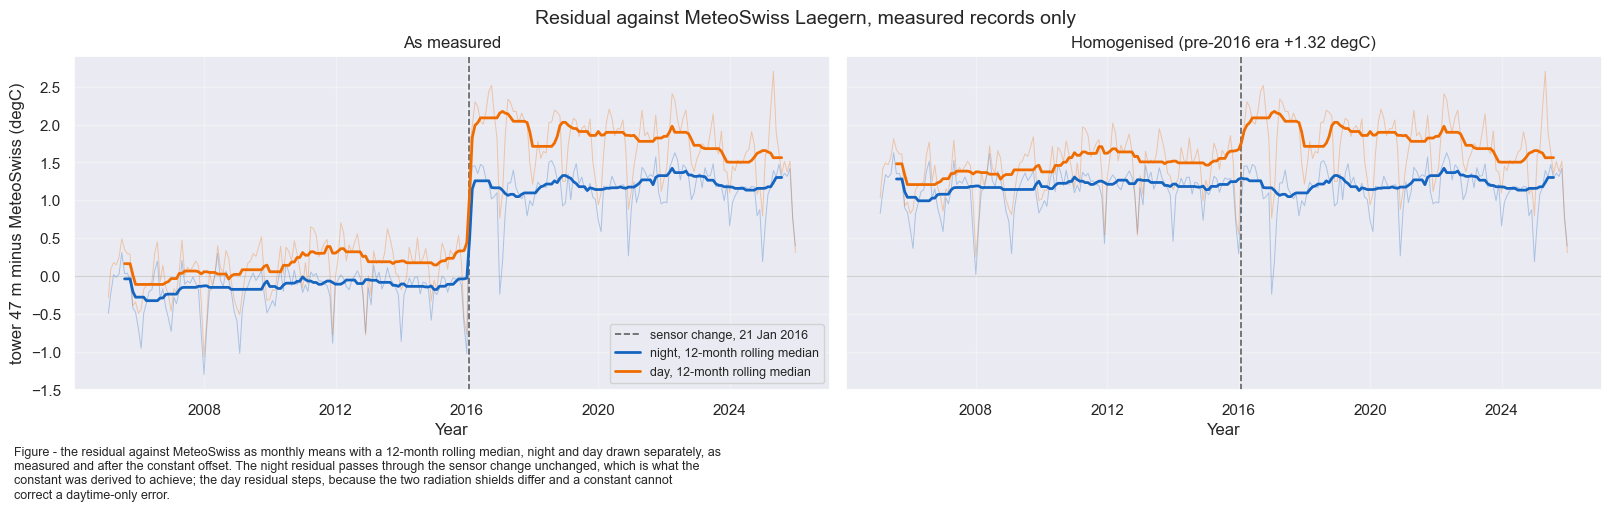

In [35]:
# The residual as monthly means with a 12-month rolling median over them, night and day drawn
# separately, before and after the correction. The rolling median is there to take the seasonal
# cycle of the difference between the two stations out of the picture; the thin line behind it is
# the monthly series it is computed from.
fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout="constrained", sharey=True)
fig.suptitle("Residual against MeteoSwiss Laegern, measured records only", fontsize=14)

for _ax, _col, _title in [(axs[0], 'measured', 'As measured'),
                          (axs[1], 'homogenised', f'Homogenised (pre-{BREAK.year} era {OFFSET:+.2f} degC)')]:
    _r = residual_check[_col] - residual_check['reference']
    _ax.axhline(0, color='#BDBDBD', lw=0.8, zorder=0)
    _ax.axvline(BREAK, color='#616161', lw=1.2, ls='--', zorder=1,
                label=f"sensor change, {BREAK:%d %b %Y}")
    for _label, _mask, _colour in [('night', _night, '#1565C0'), ('day', ~_night, '#EF6C00')]:
        _monthly = _r[_mask].resample('ME').mean()
        _ax.plot(_monthly.index, _monthly, color=_colour, lw=0.7, alpha=0.3, zorder=2)
        _ax.plot(_monthly.index, _monthly.rolling(12, center=True).median(), color=_colour, lw=2,
                 zorder=3, label=f"{_label}, 12-month rolling median")
    _ax.set_title(_title)
    _ax.set_xlabel("Year")
    _ax.grid(alpha=0.3)

axs[0].set_ylabel("tower 47 m minus MeteoSwiss (degC)")
axs[0].legend(fontsize=9, loc='lower right')
figcap(fig, "the residual against MeteoSwiss as monthly means with a 12-month rolling median, "
            "night and day drawn separately, as measured and after the constant offset. The night "
            "residual passes through the sensor change unchanged, which is what the constant was "
            "derived to achieve; the day residual steps, because the two radiation shields differ "
            "and a constant cannot correct a daytime-only error.")

In [36]:
# The same residual per year, so that the step above can be read against the ordinary
# year-to-year variation of the difference between two stations 2.5 km apart.
_res_h = residual_check['residual']
_year = _res_h.index.year
residual_per_year = pd.DataFrame({
    'night (degC)': _res_h[_night].groupby(_year[_night]).mean(),
    'day (degC)': _res_h[~_night].groupby(_year[~_night]).mean(),
    'all hours (degC)': _res_h.groupby(_year).mean(),
    'measured records': _res_h.groupby(_year).count(),
})
residual_per_year.index.name = 'YEAR'
tabcap("the residual of the homogenised column against MeteoSwiss per year, night and day. The night column carries no discontinuity at the sensor change; the day column does")
display(residual_per_year.round(2))

_night_col = residual_per_year['night (degC)']
_spread = _night_col.max() - _night_col.min()
print(f"Night residual over the whole record: {_night_col.min():.2f} to {_night_col.max():.2f} degC "
      f"(spread {_spread:.2f} degC)")
print(f"Day residual, {STEP_PRE_YEARS[0]}-{STEP_PRE_YEARS[-1]}: "
      f"{residual_per_year.loc[STEP_PRE_YEARS, 'day (degC)'].min():.2f} to "
      f"{residual_per_year.loc[STEP_PRE_YEARS, 'day (degC)'].max():.2f} degC;   "
      f"{STEP_POST_YEARS[0]}-{STEP_POST_YEARS[-1]}: "
      f"{residual_per_year.loc[STEP_POST_YEARS, 'day (degC)'].min():.2f} to "
      f"{residual_per_year.loc[STEP_POST_YEARS, 'day (degC)'].max():.2f} degC")

# The night residual of the homogenised column carries no discontinuity at the break that stands
# out from its own year-to-year variation. Stated as a comparison rather than as a threshold,
# because the threshold that matters is what the same quantity does in ordinary years.
assert abs(homogenisation_steps.loc[('night', 'homogenised'), 'step (degC)']) < _spread, (
    "the night step survives the correction at a size larger than the interannual spread of the "
    "same residual - the homogenisation is no longer supported")

Table - the residual of the homogenised column against MeteoSwiss per year, night and day. The night
column carries no discontinuity at the sensor change; the day column does



,night (degC),day (degC),all hours (degC),measured records
YEAR,,,,
2005,1.10,1.42,1.27,17486
2006,0.91,1.28,1.11,17494
2007,0.99,1.32,1.16,17507
2008,1.09,1.34,1.22,17548
2009,1.01,1.40,1.21,17036
2010,1.20,1.49,1.35,17351
2011,1.14,1.59,1.37,17499
2012,1.19,1.60,1.40,16286
2013,1.13,1.54,1.35,17434


Night residual over the whole record: 0.91 to 1.30 degC (spread 0.39 degC)
Day residual, 2013-2015: 1.47 to 1.54 degC;   2017-2019: 1.80 to 1.97 degC


The night residual passes through January 2016 without a step, and stays inside its own
year-to-year range across the whole record: there is no discontinuity at the sensor change left in
it. That is what the homogenisation was derived to achieve, confirmed by a reference that did not
produce the constant.

The daytime residual does step, and stays higher for the rest of the record. What survives the
correction therefore acts in daylight only. The cell below asks what it scales with.

Table - the daytime residual of the homogenised column binned by the radiation at the reference
station, per era. The two eras agree in the dark and separate as the sun rises



,MP101A 2013-2015 (degC),n (MP101A 2013-2015),CS215 2017-2019 (degC),n (CS215 2017-2019),difference (degC)
incoming shortwave at the reference (W m-2),,,,,
"(0, 50]",1.19,6677,1.24,6664,0.06
"(50, 100]",1.28,3613,1.44,3402,0.16
"(100, 200]",1.43,4427,1.75,4053,0.33
"(200, 300]",1.56,2931,2.08,2742,0.52
"(300, 450]",1.62,3261,2.33,3087,0.71
"(450, 600]",1.83,2282,2.47,2642,0.64
"(600, 1200]",1.94,4193,2.40,4551,0.46


Table - the same residual binned by the wind speed at the reference station, at night and in strong
sun. The reference wind does not separate the eras at either level of radiation



,"night, MP101A (degC)","night, CS215 (degC)","night, difference (degC)","day, > 300 W m-2, MP101A (degC)","day, > 300 W m-2, CS215 (degC)","day, > 300 W m-2, difference (degC)"
wind speed at the reference (m s-1),,,,,,
"(0.0, 1.5]",0.94,0.76,-0.17,1.24,1.79,0.55
"(1.5, 2.5]",0.87,0.74,-0.12,1.56,2.28,0.72
"(2.5, 3.5]",0.95,0.85,-0.10,1.90,2.50,0.60
"(3.5, 5.0]",1.11,1.04,-0.06,2.04,2.66,0.61
"(5.0, 7.0]",1.21,1.28,0.07,2.18,2.75,0.57
"(7.0, 25.0]",1.23,1.34,0.12,2.06,2.68,0.62



Era difference at 0-50 W m-2: +0.06 degC;   largest of the radiation bins: +0.71 degC
Era difference by wind speed - night: -0.17 to +0.12 degC;   strong sun: +0.55 to +0.72 degC


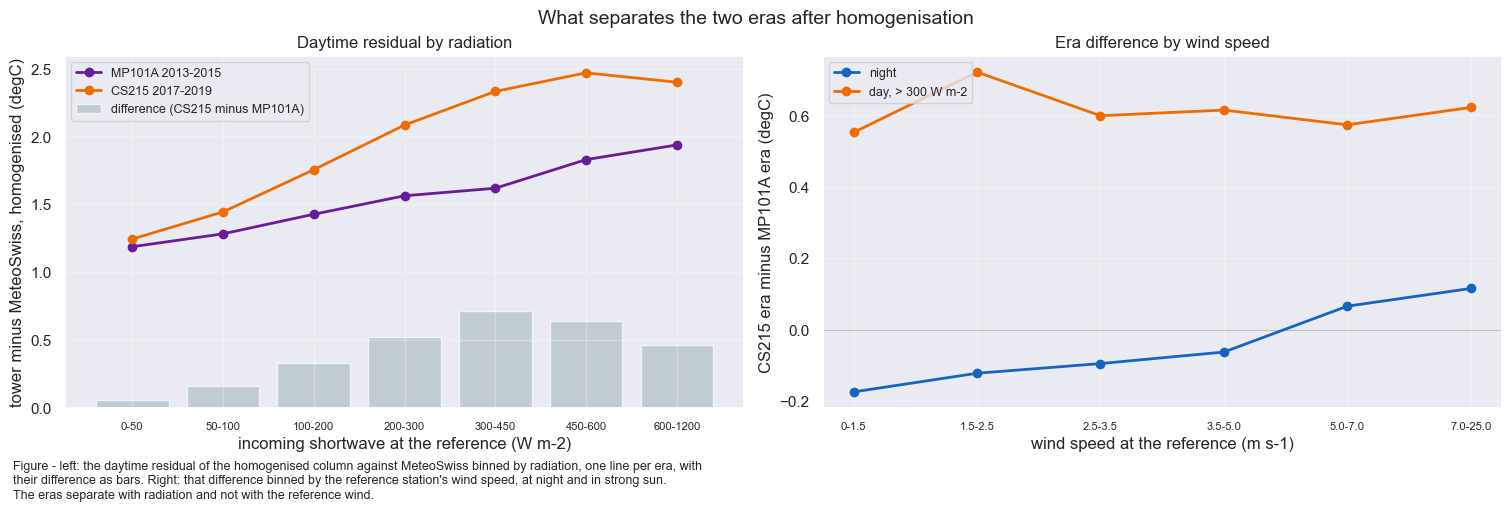

In [37]:
# What separates the two eras in daylight. The residual of the homogenised column is binned by the
# reference station's incoming shortwave and by its wind speed, over the same three years either
# side as the step table. Both come from the MeteoSwiss file, so they describe the conditions of
# the comparison; neither is measured at the tower, which matters for the wind (see below).
SW_BINS = [0, 50, 100, 200, 300, 450, 600, 1200]   # W m-2, incoming shortwave at the reference
WS_BINS = [0, 1.5, 2.5, 3.5, 5.0, 7.0, 25.0]       # m s-1, wind speed at the reference
STRONG_SUN = 300                                   # W m-2, above which the eras differ most

_eras = {f"MP101A {STEP_PRE_YEARS[0]}-{STEP_PRE_YEARS[-1]}": STEP_PRE_YEARS,
         f"CS215 {STEP_POST_YEARS[0]}-{STEP_POST_YEARS[-1]}": STEP_POST_YEARS}
_pre_name, _post_name = list(_eras)
_in_era = {_name: residual_check.index.year.isin(_years) for _name, _years in _eras.items()}

# By radiation, day records only.
_cols = {}
for _name, _sel in _in_era.items():
    _cols[f'{_name} (degC)'], _cols[f'n ({_name})'] = binned_residual(
        residual_check[_sel & ~_night], 'sw_reference', SW_BINS)
sw_profile = pd.DataFrame(_cols)
sw_profile['difference (degC)'] = (sw_profile[f'{_post_name} (degC)']
                                   - sw_profile[f'{_pre_name} (degC)'])
sw_profile.index.name = 'incoming shortwave at the reference (W m-2)'
tabcap("the daytime residual of the homogenised column binned by the radiation at the reference station, per era. The two eras agree in the dark and separate as the sun rises")
display(sw_profile.round(2))

# By wind speed, at night and in strong sun. Night is the control: whatever the wind does to the
# difference between two stations 100 m apart in elevation, it does in both eras.
_cols = {}
for _wlabel, _wsel in [('night', _night),
                       (f'day, > {STRONG_SUN} W m-2',
                        ~_night & (residual_check['sw_reference'] > STRONG_SUN))]:
    _means = {}
    for _name, _sel in _in_era.items():
        _short = _name.split()[0]
        _cols[f'{_wlabel}, {_short} (degC)'], _ = binned_residual(
            residual_check[_sel & _wsel], 'ws_reference', WS_BINS)
        _means[_short] = _cols[f'{_wlabel}, {_short} (degC)']
    _cols[f'{_wlabel}, difference (degC)'] = (_means[_post_name.split()[0]]
                                              - _means[_pre_name.split()[0]])
ws_profile = pd.DataFrame(_cols)
ws_profile.index.name = 'wind speed at the reference (m s-1)'
tabcap("the same residual binned by the wind speed at the reference station, at night and in strong sun. The reference wind does not separate the eras at either level of radiation")
display(ws_profile.round(2))

fig, axs = plt.subplots(ncols=2, figsize=(15, 5), dpi=100, layout="constrained")
fig.suptitle("What separates the two eras after homogenisation", fontsize=14)

_x = np.arange(len(sw_profile))
axs[0].axhline(0, color='#BDBDBD', lw=0.8)
axs[0].bar(_x, sw_profile['difference (degC)'], color='#B0BEC5', alpha=0.7, zorder=0,
           label='difference (CS215 minus MP101A)')
for _name, _colour in [(_pre_name, '#6A1B9A'), (_post_name, '#EF6C00')]:
    axs[0].plot(_x, sw_profile[f'{_name} (degC)'], 'o-', color=_colour, lw=2, zorder=2, label=_name)
axs[0].set_xticks(_x)
axs[0].set_xticklabels([f"{_a}-{_b}" for _a, _b in zip(SW_BINS[:-1], SW_BINS[1:])], fontsize=8)
axs[0].set_xlabel("incoming shortwave at the reference (W m-2)")
axs[0].set_ylabel("tower minus MeteoSwiss, homogenised (degC)")
axs[0].set_title("Daytime residual by radiation")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9, loc='upper left')

_x = np.arange(len(ws_profile))
axs[1].axhline(0, color='#BDBDBD', lw=0.8)
for _wlabel, _colour in [('night', '#1565C0'), (f'day, > {STRONG_SUN} W m-2', '#EF6C00')]:
    axs[1].plot(_x, ws_profile[f'{_wlabel}, difference (degC)'], 'o-', color=_colour, lw=2,
                label=_wlabel)
axs[1].set_xticks(_x)
axs[1].set_xticklabels([f"{_a}-{_b}" for _a, _b in zip(WS_BINS[:-1], WS_BINS[1:])], fontsize=8)
axs[1].set_xlabel("wind speed at the reference (m s-1)")
axs[1].set_ylabel("CS215 era minus MP101A era (degC)")
axs[1].set_title("Era difference by wind speed")
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=9, loc='upper left')
figcap(fig, "left: the daytime residual of the homogenised column against MeteoSwiss binned by "
            "radiation, one line per era, with their difference as bars. Right: that difference "
            "binned by the reference station's wind speed, at night and in strong sun. The eras "
            "separate with radiation and not with the reference wind.")

# The mechanism, asserted. In the dark the two eras agree; in sun they do not, and the separation
# grows with radiation. If that ordering ever reverses, the residual is not radiative and the
# paragraphs around this cell are wrong.
_dark = sw_profile['difference (degC)'].iloc[0]
_sunlit = sw_profile['difference (degC)'].max()
print(f"\nEra difference at {SW_BINS[0]}-{SW_BINS[1]} W m-2: {_dark:+.2f} degC;   "
      f"largest of the radiation bins: {_sunlit:+.2f} degC")
assert abs(_dark) < 0.2, "the two eras differ in the dark as well - the residual is not radiative"
assert _sunlit > 0.4, "the daytime era difference has gone - the text around this cell must be re-derived"

# The reference station's wind does not separate the eras at either level of radiation: at night
# the difference is near zero at every wind speed, and in strong sun it is near constant. That is
# not evidence against a ventilation effect at the tower, it is the reference wind failing to
# stand in for one - MeteoSwiss Laegern sits on the ridge, 2.5 km away and about 100 m higher.
_night_by_ws = ws_profile['night, difference (degC)']
_sun_by_ws = ws_profile[f'day, > {STRONG_SUN} W m-2, difference (degC)']
print(f"Era difference by wind speed - night: {_night_by_ws.min():+.2f} to {_night_by_ws.max():+.2f} degC;   "
      f"strong sun: {_sun_by_ws.min():+.2f} to {_sun_by_ws.max():+.2f} degC")
assert _night_by_ws.abs().max() < 0.25, \
    "the night era difference depends on the reference wind - the night result is not clean"
assert _sun_by_ws.min() > 0.3, \
    "the daytime era difference vanishes at some wind speed - the reading below no longer holds"

The daytime residual scales with incoming radiation. In the darkest bin the two eras are
indistinguishable, which is the night result again; as radiation rises they separate, and the
separation is largest in the sunlit middle of the range, easing again in the brightest bin. That is the signature of a radiation-shield
difference: the Campbell CS215 sits in a passive shield, the Rotronic MP101A was shielded
differently, and a difference between the two can only appear when the sun is on them. A constant
removes a constant, so none of this is removed by the homogenisation.

The reference station's wind speed does not separate the eras, at night or in strong sun. That is
not evidence against a ventilation effect at the tower: MeteoSwiss Lägern sits on the ridge
2.5 km away and about 100 m higher, so its wind is not the ventilation of the tower's shield. The
residual itself rises with that wind in both eras — two stations at different elevations agree
more closely when the air is well mixed — and the rise cancels in the difference between them. The
ventilation behaviour of the CS215 itself is measured against NABEL on the same tower, and is
stated in the limitation below.

### 🔟 Removing what a constant cannot: the shield term

The daytime residual above is the difference between the two sensors' **radiation shields**. It can
be measured, because NABEL at 49 m is aspirated: its own radiative error is negligible, and it
overlaps both eras — eleven years of the MP101A and three of the CS215. The difference
`47 m − NABEL`, taken as a function of the tower's own incoming shortwave, is therefore the shield
response of whichever sensor was in place.

Removing the **radiation-dependent part of the difference between the two responses** standardises
the CS215 era onto the MP101A era's shield behaviour, while the constant of step 8️⃣ keeps both eras
on one night level. The homogenised column exported below is that series: the night level of the
CS215 era, the daytime behaviour of the MP101A era.

Note what this does **not** do. It does not remove the MP101A era's own shield error, which both
eras then carry. It makes the record self-consistent across the sensor change, not absolutely
correct against an aspirated measurement.

The alternatives — leaving the daytime step in place, and substituting NABEL for the early years —
are scored against this construction in `TA_HOMOGENIZATION_OPTIONS.ipynb`, which is also where the
order of the polynomial is chosen and where the objections to fitting the CS215 era on three years
are tested. Only the checks that have to hold on **this** run are repeated here.

In [38]:
# Gap-filled SW_IN from notebook 01. It is loaded here rather than in the Drivers section below,
# because the shield term is a function of it; the Drivers section then reuses this object.
swin_gf = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{SWIN_FILE}.parquet"))
print(f"Loaded {SWIN_FILE}: {list(swin_gf.columns)}")
print(f"  {swin_gf.index[0]} -> {swin_gf.index[-1]} ({len(swin_gf):,} records)")
assert swin_gf[SWIN_COL].notna().all(), "the SW_IN product has gaps, so the shield term cannot be applied everywhere"

# The fit set: measured tower TA, measured NABEL and the tower's own radiation. Measured records
# only - a modelled one would report what the gap-filler was told about the eras.
shield_fit = pd.concat([ta_2004_2025[['TA_T1_47_1', 'TA_NABEL_T1_49_1']],
                        swin_gf[SWIN_COL]], axis=1).dropna()
shield_fit['bias'] = shield_fit['TA_T1_47_1'] - shield_fit['TA_NABEL_T1_49_1']
shield_fit['era'] = np.where(shield_fit.index < BREAK, 'MP101A', 'CS215')

# The order is chosen in TA_HOMOGENIZATION_OPTIONS.ipynb, on the held-out error over the three
# NABEL years of the CS215 era and on how far the curve departs from that era's own binned means.
# The second of those is re-checked below, because it is the one a changed record can invalidate.
SHIELD_ORDER = 2
SHIELD_BINS = [0, 25, 75, 150, 250, 350, 450, 550, 650, 800, 1200]
SHAPE_TOLERANCE = 0.15   # degC, largest allowed departure from an era's own binned means

print(f"\nshield fit rows: {len(shield_fit):,} "
      f"({shield_fit.index[0]:%Y-%m} to {shield_fit.index[-1]:%Y-%m})")
print(shield_fit.groupby('era').size().rename('records').to_string())
assert set(shield_fit['era']) == {'MP101A', 'CS215'}, "the shield fit set does not cover both eras"
assert shield_fit.groupby('era').size().min() > 20_000, "one era has too few records to fit"


def shield_basis(sw, order=None):
    """Polynomial design matrix in incoming shortwave, scaled to kW m-2 so the powers stay conditioned."""
    _x = np.asarray(sw, dtype=float) / 1000.0
    _order = SHIELD_ORDER if order is None else order
    return np.column_stack([_x ** _k for _k in range(1, _order + 1)] + [np.ones(len(_x))])


def fit_shield(frame):
    """Least-squares shield response against NABEL, per era. Raises on an era the frame lacks."""
    _coef = {}
    for _era in ('MP101A', 'CS215'):
        _g = frame[frame['era'] == _era]
        if len(_g) < 5_000:
            raise ValueError(f"era {_era} holds {len(_g)} rows, too few to fit a shield response")
        _beta, *_ = np.linalg.lstsq(shield_basis(_g[SWIN_COL]), _g['bias'].to_numpy(), rcond=None)
        _coef[_era] = _beta
    return _coef


def binned_shield(frame):
    """Mean bias, mean radiation and record count per radiation bin, for one era.

    The mean radiation of each bin is returned rather than the bin centre: the top bin spans
    400 W m-2 and its records sit near its lower edge, so testing or drawing it at the centre
    would place it where nothing was measured.
    """
    _g = frame.groupby(pd.cut(frame[SWIN_COL], SHIELD_BINS), observed=False)
    return pd.DataFrame({'sw': _g[SWIN_COL].mean(), 'bias': _g['bias'].mean(),
                         'records': _g['bias'].size()})

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.012 seconds).

Loaded 01_METEO_SW_IN_GAPFILLED_2004-2025: ['SW_IN_T1_47_1_gfXG', 'FLAG_SW_IN_T1_47_1_ISFILLED']
  2004-01-01 00:15:00 -> 2025-12-31 23:45:00 (385,728 records)

shield fit rows: 246,660 (2004-09 to 2018-12)
era
CS215      51600
MP101A    195060


In [39]:
# The guard guards: an era the frame does not cover must raise, not silently return one era's fit
# for both - which would make the correction below exactly zero and look like success.
try:
    fit_shield(shield_fit[shield_fit['era'] == 'MP101A'])
except ValueError as _e:
    print(f"fit_shield raises when an era is absent: {_e}")
else:
    raise AssertionError("fit_shield accepted a frame holding only one era")

fit_shield raises when an era is absent: era CS215 holds 0 rows, too few to fit a shield response


In [40]:
SHIELD = fit_shield(shield_fit)
# Beyond the radiation the fit saw, the polynomial says nothing, so it is not asked: the driver is
# clipped to the 99.9th percentile of the fitted range and the response is held flat above it.
SHIELD_SW_MAX = float(shield_fit[SWIN_COL].quantile(0.999))


def shield_bias(era, sw):
    """The fitted bias of `era` against the aspirated sensor, at one or more levels of radiation."""
    return shield_basis(np.clip(np.atleast_1d(sw), 0.0, SHIELD_SW_MAX)) @ SHIELD[era]


_rows = []
for _era in ('MP101A', 'CS215'):
    _rows.append({'era': _era, 'records': int((shield_fit['era'] == _era).sum()),
                  'bias at 0 W m-2 (degC)': shield_bias(_era, 0)[0],
                  'bias at 400 W m-2 (degC)': shield_bias(_era, 400)[0],
                  'bias at 800 W m-2 (degC)': shield_bias(_era, 800)[0]})
shield_table = pd.DataFrame(_rows).set_index('era')
shield_table['rise from 0 to 800 (degC)'] = (shield_table['bias at 800 W m-2 (degC)']
                                             - shield_table['bias at 0 W m-2 (degC)'])
tabcap("the fitted shield response of each sensor era against the aspirated NABEL sensor. The "
       "difference between the two intercepts is the zero-point error the constant removes; the "
       "difference between the two rises is what it cannot")
display(shield_table.round(3))

print(f"radiation the fit saw, 99.9th percentile: {SHIELD_SW_MAX:.0f} W m-2 (the response is held "
      f"flat above it)")
print("zero-point difference between the eras: "
      f"{shield_table.loc['CS215', 'bias at 0 W m-2 (degC)'] - shield_table.loc['MP101A', 'bias at 0 W m-2 (degC)']:+.2f} degC "
      f"against the constant of {OFFSET:+.2f} degC derived in step 8")
print("difference in the rise from 0 to 800 W m-2:  "
      f"{shield_table.loc['CS215', 'rise from 0 to 800 (degC)'] - shield_table.loc['MP101A', 'rise from 0 to 800 (degC)']:+.2f} degC")

# Both sensors must read warm relative to an aspirated one as radiation rises, and the CS215 must
# do so more. If either failed, the correction below would have the wrong sign.
for _era in ('MP101A', 'CS215'):
    assert shield_table.loc[_era, 'rise from 0 to 800 (degC)'] > 0, \
        f"the {_era} era does not warm in sun relative to the aspirated sensor"
assert (shield_table.loc['CS215', 'rise from 0 to 800 (degC)']
        > shield_table.loc['MP101A', 'rise from 0 to 800 (degC)']), \
    "the CS215 no longer warms more in sun than the MP101A - the correction would reverse sign"

# And the chosen order still describes the data. This is the check the order was selected on in
# the companion notebook, repeated here so a changed record cannot invalidate it silently.
for _era in ('MP101A', 'CS215'):
    _obs = binned_shield(shield_fit[shield_fit['era'] == _era])
    _departure = np.abs(shield_bias(_era, _obs['sw']) - _obs['bias'])
    print(f"  {_era:7s} largest departure from its own binned means: {_departure.max():.3f} degC")
    assert _departure.max() < SHAPE_TOLERANCE, (
        f"the fitted {_era} response departs from its own binned means by {_departure.max():.2f} "
        f"degC - order {SHIELD_ORDER} no longer describes the data and must be re-chosen in "
        f"TA_HOMOGENIZATION_OPTIONS.ipynb")

Table - the fitted shield response of each sensor era against the aspirated NABEL sensor. The
difference between the two intercepts is the zero-point error the constant removes; the difference
between the two rises is what it cannot



,records,bias at 0 W m-2 (degC),bias at 400 W m-2 (degC),bias at 800 W m-2 (degC),rise from 0 to 800 (degC)
era,,,,,
MP101A,195060,-1.089,-0.614,-0.676,0.413
CS215,51600,0.251,1.267,1.139,0.888


radiation the fit saw, 99.9th percentile: 980 W m-2 (the response is held flat above it)
zero-point difference between the eras: +1.34 degC against the constant of +1.32 degC derived in step 8
difference in the rise from 0 to 800 W m-2:  +0.48 degC
  MP101A  largest departure from its own binned means: 0.056 degC
  CS215   largest departure from its own binned means: 0.108 degC


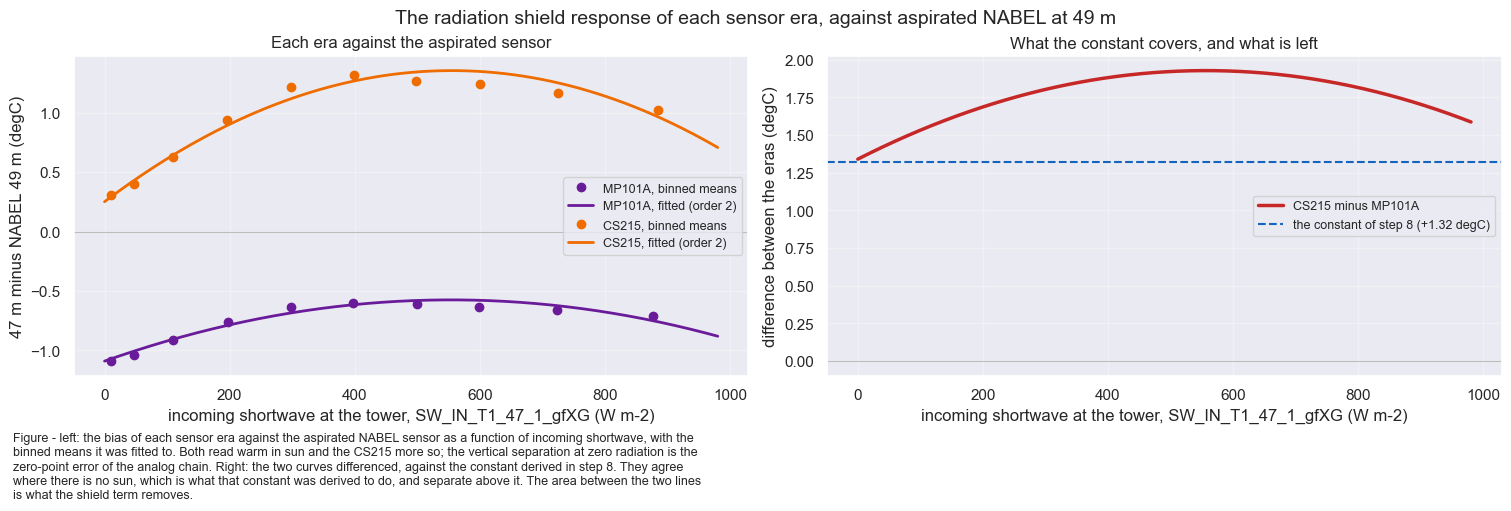

In [41]:
# The shield response, drawn against the binned data it was fitted to. The curves are drawn only
# over the range the fit saw, and the binned means at each bin's own mean radiation.
_grid = np.linspace(0, SHIELD_SW_MAX, 200)
fig, axs = plt.subplots(ncols=2, figsize=(15, 5), dpi=100, layout="constrained")
fig.suptitle("The radiation shield response of each sensor era, against aspirated NABEL at 49 m",
             fontsize=14)

for _era, _colour in [('MP101A', '#6A1B9A'), ('CS215', '#EF6C00')]:
    _obs = binned_shield(shield_fit[shield_fit['era'] == _era])
    axs[0].plot(_obs['sw'], _obs['bias'], 'o', color=_colour, ms=6, label=f"{_era}, binned means")
    axs[0].plot(_grid, shield_bias(_era, _grid), '-', color=_colour, lw=2,
                label=f"{_era}, fitted (order {SHIELD_ORDER})")
axs[0].axhline(0, color='#BDBDBD', lw=0.8)
axs[0].set_xlabel(f"incoming shortwave at the tower, {SWIN_COL} (W m-2)")
axs[0].set_ylabel("47 m minus NABEL 49 m (degC)")
axs[0].set_title("Each era against the aspirated sensor")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9)

axs[1].plot(_grid, shield_bias('CS215', _grid) - shield_bias('MP101A', _grid), color='#C62828',
            lw=2.5, label='CS215 minus MP101A')
axs[1].axhline(OFFSET, color='#1565C0', lw=1.5, ls='--',
               label=f"the constant of step 8 ({OFFSET:+.2f} degC)")
axs[1].axhline(0, color='#BDBDBD', lw=0.8)
axs[1].set_xlabel(f"incoming shortwave at the tower, {SWIN_COL} (W m-2)")
axs[1].set_ylabel("difference between the eras (degC)")
axs[1].set_title("What the constant covers, and what is left")
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=9)
figcap(fig, "left: the bias of each sensor era against the aspirated NABEL sensor as a function of "
            "incoming shortwave, with the binned means it was fitted to. Both read warm in sun and "
            "the CS215 more so; the vertical separation at zero radiation is the zero-point error "
            "of the analog chain. Right: the two curves differenced, against the constant derived "
            "in step 8. They agree where there is no sun, which is what that constant was derived "
            "to do, and separate above it. The area between the two lines is what the shield term "
            "removes.")

In [42]:
# The correction. Two terms acting on different eras, and neither touches the other's records.
def radiative_excess(sw):
    """The radiation-dependent part of the CS215-minus-MP101A difference, in degC.

    Zero where there is no sun, by construction: the zero-radiation part of that difference is the
    zero-point error of the analog chain, which OFFSET already removes. Subtracting it here as well
    would correct the night twice.
    """
    _x = shield_basis(np.clip(np.atleast_1d(sw), 0.0, SHIELD_SW_MAX))
    _x0 = shield_basis(np.zeros(len(np.atleast_1d(sw))))
    return (_x - _x0) @ (SHIELD['CS215'] - SHIELD['MP101A'])


def homogenize(values, index, sw):
    """The homogenised series: one night level and one daytime shield behaviour for both eras."""
    _out = np.asarray(values, dtype=float) + np.where(index < BREAK, OFFSET, 0.0)
    return _out - np.where(index >= BREAK, radiative_excess(sw), 0.0)


# The guard guards. At zero radiation the excess must be exactly zero, or every night record of
# the CS215 era would move and the constant of step 8 would be corrected twice.
assert abs(radiative_excess([0.0])[0]) < 1e-12, \
    "the radiative term is not zero in the dark - it would correct the night level a second time"
# And it must be positive in sun: the CS215 reads warmer than the MP101A there, so the correction
# can only ever cool the later era.
_probe = radiative_excess(np.linspace(0, SHIELD_SW_MAX, 50))
assert (_probe >= -1e-9).all(), \
    "the radiative term turns negative inside the fitted range - it would warm the CS215 era"
print(f"radiative excess of the CS215 shield: 0.00 degC in the dark, "
      f"{_probe.max():+.2f} degC at most, at {np.linspace(0, SHIELD_SW_MAX, 50)[_probe.argmax()]:.0f} W m-2")

# What it does to the residual of step 9, on measured records only and against MeteoSwiss - which
# entered neither the constant nor the shield fit.
residual_check['shield'] = homogenize(residual_check['measured'],
                                      residual_check.index,
                                      swin_gf[SWIN_COL].reindex(residual_check.index))
_rows = []
for _wname, _wmask in _windows:
    for _col in ['measured', 'homogenised', 'shield']:
        _n, _a, _b = residual_step(residual_check[_col] - residual_check['reference'], _wmask,
                                   STEP_PRE_YEARS, STEP_POST_YEARS)
        _rows.append({'window': _wname, 'column': _col, _pre_label: _a, _post_label: _b,
                      'step (degC)': _b - _a, 'records': _n})
shield_steps = pd.DataFrame(_rows).set_index(['window', 'column'])
tabcap("the step across the sensor change against MeteoSwiss, for the series as measured, after "
       "the constant alone, and after the constant and the shield term together. 'shield' is the "
       "column exported below")
display(shield_steps.round(2))

_day_before = shield_steps.loc[('day', 'homogenised'), 'step (degC)']
_day_after = shield_steps.loc[('day', 'shield'), 'step (degC)']
_night_after = shield_steps.loc[('night', 'shield'), 'step (degC)']
print(f"\nDaytime step: {_day_before:+.2f} degC with the constant alone, {_day_after:+.2f} degC "
      f"with the shield term as well.")
print(f"Night step:   {_night_after:+.2f} degC, unchanged by the shield term as it must be.")

# The shield term must not undo what step 8 achieved at night.
assert abs(_night_after - shield_steps.loc[('night', 'homogenised'), 'step (degC)']) < 0.02, \
    "the shield term moved the night step, which it is defined not to do"
# And it must remove most of the daytime step, or it is not worth the column it changes.
assert abs(_day_after) < 0.5 * abs(_day_before), (
    f"the shield term reduces the daytime step from {_day_before:+.2f} to only {_day_after:+.2f} "
    f"degC - less than half, which is not what TA_HOMOGENIZATION_OPTIONS.ipynb measured")

radiative excess of the CS215 shield: 0.00 degC in the dark, +0.59 degC at most, at 560 W m-2


Table - the step across the sensor change against MeteoSwiss, for the series as measured, after the
constant alone, and after the constant and the shield term together. 'shield' is the column exported
below



2013-2015 (degC)  2017-2019 (degC)  step (degC)  records
window    column                                                               
night     measured                -0.21              1.10         1.31    49680
          homogenised              1.11              1.10        -0.01    49680
          shield                   1.11              1.10        -0.01    49680
day       measured                 0.18              1.87         1.69    54532
          homogenised              1.50              1.87         0.37    54532
          shield                   1.50              1.56         0.06    54532
all hours measured                -0.01              1.50         1.51   104212
          homogenised              1.31              1.50         0.19   104212
          shield                   1.31              1.34         0.03   104212


Daytime step: +0.37 degC with the constant alone, +0.06 degC with the shield term as well.
Night step:   -0.01 degC, unchanged by the shield term as it must be.


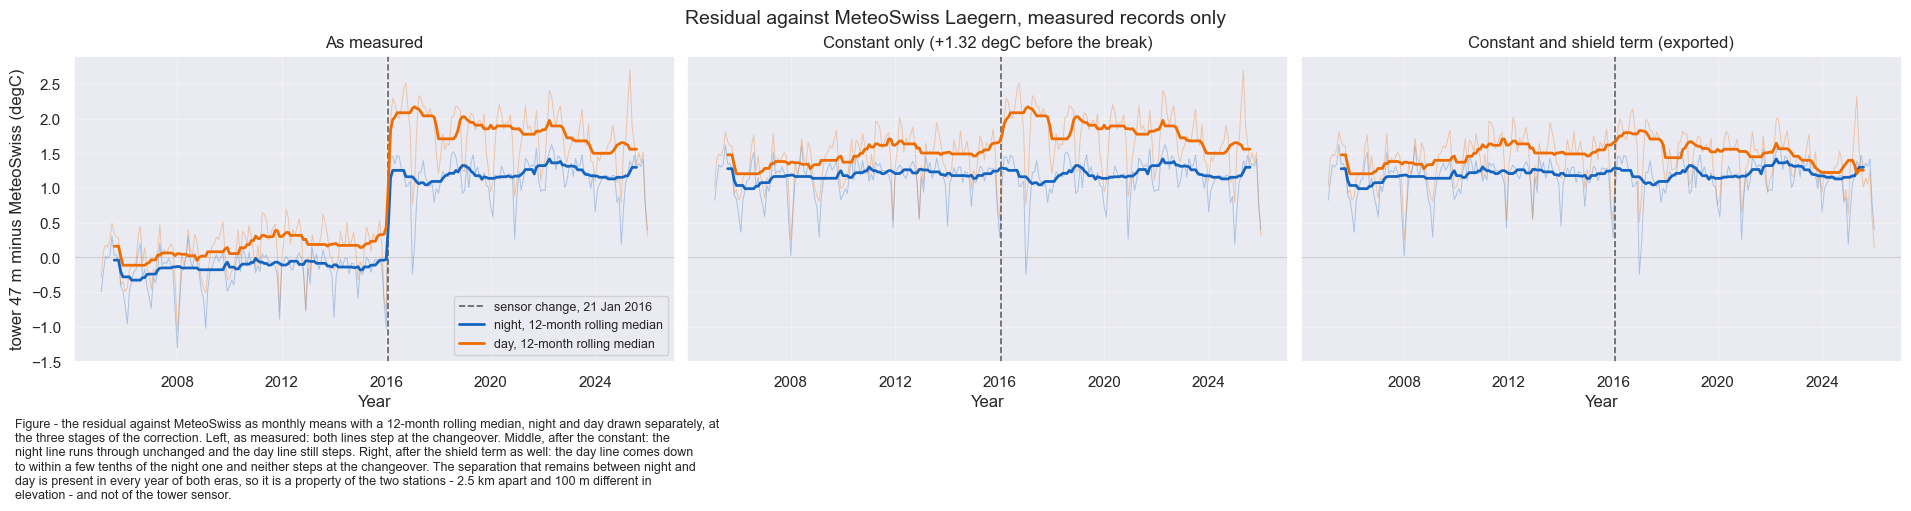

In [43]:
# The figure of step 9, redrawn with the shield term added as a third panel. Same axes, same
# night/day split, same reference - so the three panels are the record before any correction,
# after the constant, and after both terms, and can be read across.
fig, axs = plt.subplots(ncols=3, figsize=(19, 5), dpi=100, layout="constrained", sharey=True)
fig.suptitle("Residual against MeteoSwiss Laegern, measured records only", fontsize=14)

for _ax, _col, _title in [
        (axs[0], 'measured', 'As measured'),
        (axs[1], 'homogenised', f'Constant only ({OFFSET:+.2f} degC before the break)'),
        (axs[2], 'shield', 'Constant and shield term (exported)')]:
    _r = residual_check[_col] - residual_check['reference']
    _ax.axhline(0, color='#BDBDBD', lw=0.8, zorder=0)
    _ax.axvline(BREAK, color='#616161', lw=1.2, ls='--', zorder=1,
                label=f"sensor change, {BREAK:%d %b %Y}")
    for _label, _mask, _colour in [('night', _night, '#1565C0'), ('day', ~_night, '#EF6C00')]:
        _monthly = _r[_mask].resample('ME').mean()
        _ax.plot(_monthly.index, _monthly, color=_colour, lw=0.7, alpha=0.3, zorder=2)
        _ax.plot(_monthly.index, _monthly.rolling(12, center=True).median(), color=_colour, lw=2,
                 zorder=3, label=f"{_label}, 12-month rolling median")
    _ax.set_title(_title)
    _ax.set_xlabel("Year")
    _ax.grid(alpha=0.3)

axs[0].set_ylabel("tower 47 m minus MeteoSwiss (degC)")
axs[0].legend(fontsize=9, loc='lower right')
figcap(fig, "the residual against MeteoSwiss as monthly means with a 12-month rolling median, "
            "night and day drawn separately, at the three stages of the correction. Left, as "
            "measured: both lines step at the changeover. Middle, after the constant: the night "
            "line runs through unchanged and the day line still steps. Right, after the shield "
            "term as well: the day line comes down to within a few tenths of the night one and "
            "neither steps at the changeover. The separation that remains between night and day "
            "is present in every year of both eras, so it is a property of the two stations - "
            "2.5 km apart and 100 m different in elevation - and not of the tower sensor.")

The daytime step is cut to a fraction of what the constant alone leaves, and the night step is
untouched. What remains is not a step at the sensor change but the ordinary disagreement between
two stations 2.5 km apart, resolved by radiation: the residual still rises with sun in both eras,
because the MP101A era's own shield error is present in both and is not corrected here.

#### What the break does to the numbers this product is used for

Quoted figures go stale as soon as anything upstream changes, so the ones this notebook states are
computed here. They use **measured records only**, so the gap-filling has no influence on them.


In [44]:
# Yearly means from measured records only, before and after the correction. The correction is
# the full one - the constant and the shield term - so these are the figures the exported
# homogenised column produces, and the comparison against it in the export section is like for
# like. The shield term acts per record rather than per year, so it is applied before resampling.
#
# 2016 is excluded from BOTH periods, as in the evidence table above: the changeover happened
# inside it, so it belongs to neither era - and its measured mean is missing the first three weeks
# of January, which on its own would make the year read warm.
#
# A yearly mean here is the mean of whatever was measured that year, so a year with a long removal
# window is weighted by the part of it that survived. The record counts are shown for that reason:
# 2012 lost about 1,200 records, most of them in summer.
_meas_series = ta_2004_2025['TA_T1_47_1']
_homog_series = pd.Series(
    homogenize(_meas_series, _meas_series.index, swin_gf[SWIN_COL].reindex(_meas_series.index)),
    index=_meas_series.index).where(_meas_series.notna())

_ymeas = _meas_series.resample('YE').mean()
_ncount = _meas_series.resample('YE').count()
_yhomog = _homog_series.resample('YE').mean()
_yhomog.index = _yhomog.index.year
_ymeas.index, _ncount.index = _ymeas.index.year, _ncount.index.year
_ymeas = _ymeas.loc[2005:]          # 2004 has no measurement before 20 September
_ncount = _ncount.loc[2005:]
# Eras are split by whole calendar year here, which is only correct because the break year holds
# no measurement before the break. For a mid-year break this would silently mix the two eras
# inside one annual mean.
_bk = ta_2004_2025.loc[ta_2004_2025.index.year == BREAK.year, 'TA_T1_47_1']
assert _bk[_bk.index < BREAK].notna().sum() == 0, (
    f"{BREAK.year} holds measurements before the break, so an era split by calendar year mixes "
    f"the two sensors inside that year's mean")

_yhomog = _yhomog.loc[2005:]

_split = BREAK.year
_early = _ymeas.index < _split
_recent = _ymeas.index > _split     # strictly greater: 2016 is in neither period

tabcap("yearly means from measured records only, as the instrument reported them and after the "
       "full correction, with the era each year belongs to. The break year is in neither period")
display(pd.DataFrame({'measured (degC)': _ymeas, 'homogenised (degC)': _yhomog,
                      'measured records': _ncount,
                      'period': np.where(_early, f'{_ymeas.index.min()}-{_split - 1}',
                                         np.where(_recent, f'{_split + 1}-{_ymeas.index.max()}',
                                                  'excluded'))}).round(2))

_rows = []
for _name, _s in [('as measured', _ymeas), ('homogenised', _yhomog)]:
    _slope, _, _lo, _hi = theilslopes(_s.to_numpy(float), _s.index.to_numpy(float), alpha=0.95)
    _tau, _p = kendalltau(_s.index.to_numpy(float), _s.to_numpy(float))
    _rows.append({'series': _name,
                  f'{_ymeas.index.min()}-{_split - 1} (degC)': _s[_early].mean(),
                  f'{_split + 1}-{_ymeas.index.max()} (degC)': _s[_recent].mean(),
                  'difference (degC)': _s[_recent].mean() - _s[_early].mean(),
                  'Theil-Sen (degC/decade)': _slope * 10,
                  'lower 95 %': _lo * 10, 'upper 95 %': _hi * 10,
                  'Kendall tau': _tau, 'p': _p})
# Kept as a name: the export section shows it beside the same figures computed from the finished
# columns, because the two do not agree and the reason is worth stating.
headline_measured = pd.DataFrame(_rows).set_index('series')
tabcap("the period difference and the trend, as measured and homogenised, from measured records "
       "only. The whole of the change between the two rows is instrumental: the constant lifts the "
       "earlier era and the shield term cools the later one")
display(headline_measured.round(3))
# The two terms move the two periods in opposite directions, so the size of each is stated
# rather than left to be read off the table.
_early_shift = (_yhomog[_early] - _ymeas[_early]).mean()
_recent_shift = (_yhomog[_recent] - _ymeas[_recent]).mean()
print(f"The correction raises the {_split - 1}-and-earlier years by {_early_shift:+.2f} degC (the "
      f"constant, applied whole)\nand lowers the {_split + 1}-and-later ones by "
      f"{abs(_recent_shift):.2f} degC (the shield term, which depends on radiation\nand so averages "
      f"to less than its maximum). Both are instrumental, so the whole of the change in the\nperiod "
      f"difference and in the trend is the instrument, not the climate.")
print(f"The trend uses every year including {_split}; only the two period means exclude it.")

assert abs(_early_shift - OFFSET) < 1e-9, \
    "the earlier era no longer moves by exactly the constant, which is what it is defined to do"
assert _recent_shift < 0, \
    "the shield term no longer cools the later era - it can only ever remove warming"

Table - yearly means from measured records only, as the instrument reported them and after the full
correction, with the era each year belongs to. The break year is in neither period



,measured (degC),homogenised (degC),measured records,period
TIMESTAMP_MIDDLE,,,,
2005,7.46,8.77,17486,2005-2015
2006,7.96,9.28,17494,2005-2015
2007,8.11,9.43,17507,2005-2015
2008,7.59,8.91,17548,2005-2015
2009,7.66,8.98,17036,2005-2015
2010,6.68,8.00,17351,2005-2015
2011,8.78,10.10,17499,2005-2015
2012,7.57,8.89,16306,2005-2015
2013,7.08,8.40,17434,2005-2015


Table - the period difference and the trend, as measured and homogenised, from measured records
only. The whole of the change between the two rows is instrumental: the constant lifts the earlier
era and the shield term cools the later one



,2005-2015 (degC),2017-2025 (degC),difference (degC),Theil-Sen (degC/decade),lower 95 %,upper 95 %,Kendall tau,p
series,,,,,,,,
as measured,7.848,10.323,2.475,1.802,1.16,2.483,0.590,0.000
homogenised,9.168,10.163,0.995,0.767,0.29,1.282,0.467,0.003


The correction raises the 2015-and-earlier years by +1.32 degC (the constant, applied whole)
and lowers the 2017-and-later ones by 0.16 degC (the shield term, which depends on radiation
and so averages to less than its maximum). Both are instrumental, so the whole of the change in the
period difference and in the trend is the instrument, not the climate.
The trend uses every year including 2016; only the two period means exclude it.


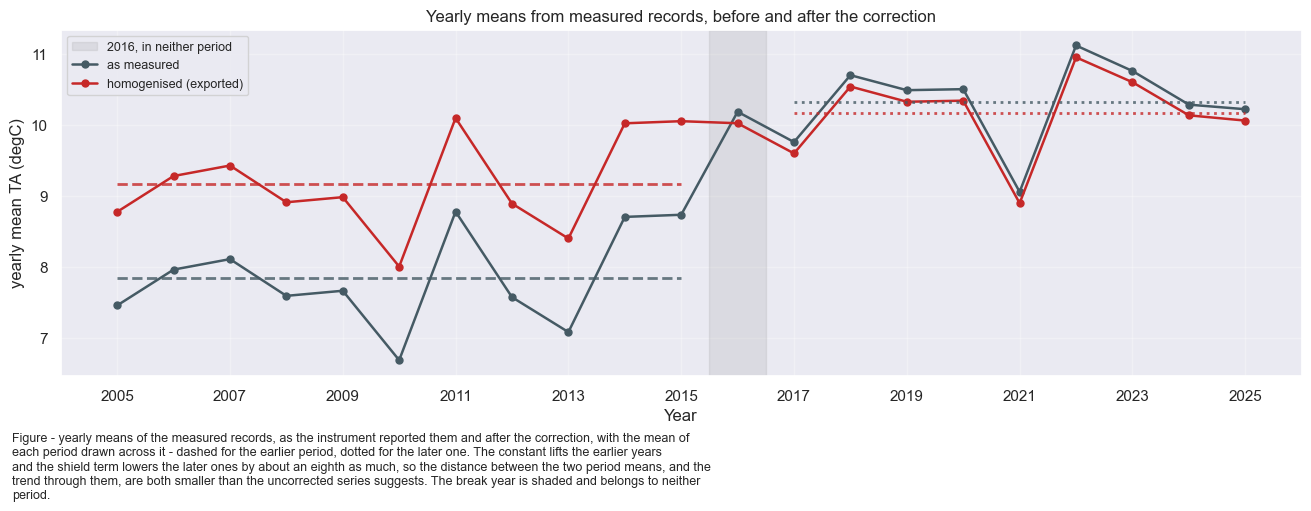

In [45]:
# The two columns as yearly means, with the periods the table above compares. Drawn from the same
# arrays, so the figure cannot disagree with the numbers beside it.
fig, ax = plt.subplots(figsize=(13, 5), dpi=100, layout="constrained")
ax.axvspan(_split - 0.5, _split + 0.5, color='#9E9E9E', alpha=0.2,
           label=f"{_split}, in neither period")
ax.plot(_ymeas.index, _ymeas.to_numpy(), 'o-', color='#455A64', lw=1.8, ms=5, label='as measured')
ax.plot(_yhomog.index, _yhomog.to_numpy(), 'o-', color='#C62828', lw=1.8, ms=5,
        label='homogenised (exported)')
for _s, _colour in [(_ymeas, '#455A64'), (_yhomog, '#C62828')]:
    for _mask, _style in [(_early, '--'), (_recent, ':')]:
        ax.hlines(_s[_mask].mean(), _s.index[_mask].min(), _s.index[_mask].max(),
                  color=_colour, lw=2, ls=_style, alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("yearly mean TA (degC)")
ax.set_title("Yearly means from measured records, before and after the correction")
ax.set_xticks(list(_ymeas.index)[::2])
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
figcap(fig, "yearly means of the measured records, as the instrument reported them and after the "
            "correction, with the mean of each period drawn across it - dashed for the earlier "
            "period, dotted for the later one. The constant lifts the earlier years and the shield "
            "term lowers the later ones by about an eighth as much, so the distance between the "
            "two period means, and the trend through them, are both smaller than the uncorrected "
            "series suggests. The "
            "break year is shaded and belongs to neither period.")

#### What the correction does not fix

The first item is measured in steps 9️⃣ and 🔟 above, against MeteoSwiss, which entered neither
term of the correction. The step tables there report each figure on three complete years either
side of the break and, for the constant, over the full eras as well; the two windows agree, so
none of it is an artefact of the window.

- **The shield error the two sensors share is still there.** The correction standardises the CS215
  era onto the MP101A era's shield behaviour, not onto an aspirated measurement, so both eras keep
  the MP101A's own error: they read warm in sun and light wind throughout the record. **Daily
  maxima and diurnal ranges are therefore biased warm in every year** — but by a comparable amount
  on both sides of 2016, which is what makes them comparable across it. The residual step that
  does survive is the `shield` row of the step table in step 🔟. Removing the shared error as well
  would mean putting the record on the aspirated scale, which is recorded above as rejected and
  scored in `TA_HOMOGENIZATION_OPTIONS.ipynb`.
- **The radiative term is a function of a gap-filled driver.** It is computed from
  `SW_IN_T1_47_1_gfXG`, so where that product is modelled the correction rests on a modelled
  radiation value. The companion notebook measures what this costs by refitting on measured
  radiation alone; it is hundredths of a degree, because the driver is almost complete over the
  era the term is applied to.
- **The records reconstructed from NABEL carry too little scatter.** A fitted line has no
  residual, so those 1,530 values sit about 0.05 °C from NABEL where a real measurement sits about
  0.25 °C from it. Their means are sound; **variance, extremes and any statistic of spread computed
  over the periods they cover are understated.** They are concentrated in January 2004 but not
  confined to it — the export section prints the breakdown by month.
- **2004 has no measurement before 20 September.** 72 % of that year is modelled throughout, and
  January is reconstructed from NABEL rather than gap-filled, because MeteoSwiss does not begin
  until 1 February 2004. It carries source code `3` and is the least constrained year.
- **The mechanism of the zero-point error is inferred.** The class of error is established;
  whether the eleven millivolts came from the probe's zero trim or from a ground offset in the
  cabling is not.

***

***

## 🟦 Drivers

Three drivers feed the gap-filling, all covering the whole record:

- **Gap-filled `SW_IN`** from notebook `01` — incoming radiation drives the daily temperature
  cycle, the most useful measured predictor here. Notebook `01` must be run first. It is
  already loaded: the break section above fits the shield term against it.
- **`SW_IN_POT`**, potential radiation from the site coordinates — day length and season in one
  gap-free variable.
- **MeteoSwiss Lägern `TA_LAE_MS`** — an independent temperature measurement 2.5 km away, added
  below with an alignment guard.

NABEL (`TA_NABEL_T1_49_1`) is added per period, where available.

In [46]:
# SW_IN_POT from the site coordinates.
swinpot = dv.variables.potrad(
    timestamp_index=ta_2004_2025.index,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)

drivers = pd.DataFrame(index=ta_2004_2025.index)
drivers[SWIN_COL] = swin_gf[SWIN_COL]  # keeps the name it has in the file; aligned on the index
drivers['SW_IN_POT'] = swinpot

# Both drivers must be complete, otherwise records fall back to the timestamp-only model.
print(drivers.isnull().sum().rename('missing values'))
drivers.describe()

SW_IN_T1_47_1_gfXG    0
SW_IN_POT             0
Name: missing values, dtype: int64


,SW_IN_T1_47_1_gfXG,SW_IN_POT
count,385728.000000,385728.000000
mean,145.881536,298.951202
std,240.172173,382.633189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,4.033335,17.494992
75%,197.979111,566.632430
max,1118.658439,1214.125501


### 🌍 MeteoSwiss Lägern

An independent air-temperature measurement 2.5 km away, added to `drivers` so it feeds both
gap-filling runs. It carries `TIMESTAMP_END`; this notebook works on `TIMESTAMP_MID`, so the index
is shifted back 15 minutes (the midpoint of a 30MIN bin). The guard correlates it against the
measured tower `TA` at several offsets and asserts that offset 0 wins — a mis-shifted reference
would teach the model the wrong daily cycle with nothing in the output to show it.

In [47]:
ta_ref = pd.read_parquet(REFPATH)[[REFCOL]]
ta_ref.index = ta_ref.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
ta_ref.index.name = ta_2004_2025.index.name

_meas = ta_2004_2025['TA_T1_47_1']
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), ta_ref[REFCOL].shift(_off).rename('r')], axis=1).dropna()
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

drivers[REFCOL] = ta_ref[REFCOL]
print(f"\n{REFCOL} available for {drivers[REFCOL].notna().mean() * 100:.2f}% of records")
drivers.describe()

  offset -1 x 30min: corr 0.9890
  offset +0 x 30min: corr 0.9893


  offset +1 x 30min: corr 0.9878
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

TA_LAE_MS available for 99.54% of records


,SW_IN_T1_47_1_gfXG,SW_IN_POT,TA_LAE_MS
count,385728.000000,385728.000000,383968.000000
mean,145.881536,298.951202,8.331966
std,240.172173,382.633189,7.879658
min,0.000000,0.000000,-17.700000
25%,0.000000,0.000000,2.266667
50%,4.033335,17.494992,8.333333
75%,197.979111,566.632430,14.233333
max,1118.658439,1214.125501,32.900000


***

## 🟪 Prepare dataframes

Split into the three periods that are gap-filled separately. There are two boundaries and they
exist for different reasons:

- **the sensor change on 21 January 2016.** A model trained across it sees one target with a
  1.3 °C discontinuity in it, and the values it produces belong to neither era. This boundary is
  not optional: it is what makes the homogenisation valid for filled records as well as for
  measured ones.
- **the end of NABEL**, which is a change of *drivers* rather than of instruments.

The January 2016 outage itself is filled with the earlier period, so that the offset region and
the first period cover exactly the same span. The measured column then steps at the sensor change
and nowhere else, and the homogenised column is continuous across it.

Both cut-offs are taken from the data rather than hard-coded.


In [48]:
# Last year in which NABEL delivers a usable amount of data.
_nabel_per_year = ta_2004_2025['TA_NABEL_T1_49_1'].groupby(ta_2004_2025.index.year).count()
print("NABEL records per year:")
print(_nabel_per_year.to_string())
NABEL_LAST_YEAR = int(_nabel_per_year[_nabel_per_year > 0].index.max())
print(f"\nNABEL is used as driver up to and including {NABEL_LAST_YEAR}.")

# The three periods. P1 ends on the last record before the sensor change, so it carries the
# January 2016 outage: those records are modelled, and filling them with the earlier model puts
# them on the earlier era's level, which is what the offset below then corrects.
_nabel_end = ta_2004_2025.loc[:f"{NABEL_LAST_YEAR}-12-31 23:59"].index[-1]
PERIODS = {
    'P1': dict(start=ta_2004_2025.index[0], stop=BREAK - pd.Timedelta('30min'), use_nabel=True,
               label=f'MP101A era, NABEL available (to {(BREAK - pd.Timedelta("30min")):%d %b %Y})'),
    'P2': dict(start=BREAK, stop=_nabel_end, use_nabel=True,
               label=f'CS215 era, NABEL available (to {_nabel_end:%d %b %Y})'),
    'P3': dict(start=_nabel_end + pd.Timedelta('30min'), stop=ta_2004_2025.index[-1],
               use_nabel=False, label='CS215 era, NABEL has stopped'),
}

_summary = []
for _k, _p in PERIODS.items():
    _slice = ta_2004_2025.loc[_p['start']:_p['stop']]
    _summary.append({'period': _k, 'label': _p['label'],
                     'from': _p['start'], 'to': _p['stop'], 'records': len(_slice),
                     'measured': int(_slice['TA_T1_47_1'].notna().sum()),
                     'NABEL as driver': _p['use_nabel']})
tabcap("the three gap-filling periods, their boundaries and how much of each was measured. No model is fitted across the sensor change")
display(pd.DataFrame(_summary).set_index('period'))

# The periods must tile the record exactly once, and none may span the sensor change - that is the
# whole point of the split, and it is cheap to assert.
_covered = pd.concat([pd.Series(True, index=ta_2004_2025.loc[_p['start']:_p['stop']].index)
                      for _p in PERIODS.values()])
assert len(_covered) == len(ta_2004_2025), \
    f"the periods cover {len(_covered)} of {len(ta_2004_2025)} records"
assert not _covered.index.duplicated().any(), "the periods overlap"
assert _covered.index.equals(ta_2004_2025.index), "the periods do not tile the record in order"
for _k, _p in PERIODS.items():
    assert not (_p['start'] < BREAK < _p['stop']), \
        f"period {_k} spans the sensor change - a model trained on it would learn both eras"
print("\nOK: three periods, tiling the record exactly once, none spanning the sensor change.")


NABEL records per year:
TIMESTAMP_MIDDLE
2004    17508
2005    17266
2006    17515
2007    17508
2008    17561
2009    17507
2010    17441
2011    17500
2012    17453
2013    17519
2014    17518
2015    17516
2016    17557
2017    17514
2018    17520
2019        0
2020        0
2021        0
2022        0
2023        0
2024        0
2025        0

NABEL is used as driver up to and including 2018.
Table - the three gap-filling periods, their boundaries and how much of each was measured. No model
is fitted across the sensor change



,label,from,to,records,measured,NABEL as driver
period,,,,,,
P1,"MP101A era, NABEL available (to 21 Jan 2016)",2004-01-01 00:15:00,2016-01-21 13:45:00,211372,195592,True
P2,"CS215 era, NABEL available (to 31 Dec 2018)",2016-01-21 14:15:00,2018-12-31 23:45:00,51620,51612,True
P3,"CS215 era, NABEL has stopped",2019-01-01 00:15:00,2025-12-31 23:45:00,122736,121861,False



OK: three periods, tiling the record exactly once, none spanning the sensor change.


***

## 🟥 Gap-filling

### Method

Notebook `01` uses `SWINGapFillerXGBoost`, which is built specifically for radiation: it sets
nighttime gaps to zero, clips negative predictions to zero, removes a nighttime sensor offset and
interpolates the clearness index `SW_IN/SW_IN_POT`. **None of that is valid for temperature** —
it would put 0 °C into every night-time gap and turn every frost gap into 0 °C.

This notebook therefore uses the general `XGBoostTS` gap-filler with an explicit
`FeatureEngineer`, which is what `SWINGapFillerXGBoost` wraps internally. Everything else follows
notebook `01`: the same drivers-plus-timestamp feature idea, SHAP-based feature reduction, and
short gaps filled by interpolation rather than by the model.

Four settings are worth understanding:

- **`features_lag=[]`.** The model only predicts records where every feature is present. A lag of
  a driver that has gaps turns "my neighbour is missing" into "I cannot be filled", which pushes
  records to the weaker timestamp-only fallback.
- **`SW_IN_POT` is excluded from the rolling and EMA stages.** It follows from the timestamp
  alone, so smoothed versions of it repeat what its raw value and the timestamp features already
  say. Including it added 14 features here and changed the score in the fourth decimal.
- **`shap_max_rows=10_000`.** SHAP importances are the slowest part of a run, they are computed
  four times per call (train, reduce, retrain, fill), and the cost grows with the number of rows
  and trees. The mean importances settle long before the full record is used, so the rows are
  capped — the same cap `SWINGapFillerXGBoost` applies. Predictions and scores are untouched;
  only the importances (and therefore the feature reduction) read the capped sample, which stays
  reproducible through `random_state`.
- **Hyperparameters are given explicitly.** Unlike `SWINGapFillerXGBoost`, the general `XGBoostTS`
  ships no tuned defaults, so the values that class uses for radiation are set here by hand.

**Short gaps** (up to 1 h) are filled by linear interpolation afterwards and flagged `4`. The
model never sees the target's own neighbours, because the feature engineer excludes the target
from its own features, so a short gap is exactly the case it is blind to. Unlike radiation,
temperature is continuous across midnight, so the interpolation is not restricted to single days
here.

In [49]:
SHAP_MAX_ROWS = 10_000  # rows used for SHAP importances, see the note above


def short_gap_mask(series: pd.Series, limit: int) -> pd.Series:
    """True where `series` is missing AND its whole gap is at most `limit` records long.

    Whole runs are selected explicitly. Using pandas' `interpolate(limit=)` instead would fill
    the first `limit` records of a long gap as well, which is not wanted: those values would sit
    on a straight line spanning the entire gap.
    """
    missing = series.isna()
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def gapfill_ta(target: pd.Series,
               drivers: pd.DataFrame,
               interpolate_limit: int = 2,
               reduce_features: bool = True,
               verbose: int = 1):
    """Gap-fill a temperature series with XGBoost, then interpolate the remaining short gaps.

    Returns (model, gapfilled, flag). `gapfilled` carries the `_gfXG` name, `flag` follows
    FLAG_LEGEND.
    """
    input_df = pd.concat([target, drivers], axis=1)

    engineer = dv.gapfilling.FeatureEngineer(
        target_col=target.name,
        features_lag=[],  # see the note above
        features_rolling=[4, 8, 24, 48],  # 2h, 4h, 12h, 24h on 30MIN data
        features_rolling_stats=['median'],
        features_rolling_exclude_cols=['SW_IN_POT'],  # deterministic, see the note above
        features_ema=[6, 24],  # 3h, 12h
        features_ema_exclude_cols=['SW_IN_POT'],
        vectorize_timestamps=True,
        add_continuous_record_number=True,
        verbose=0,
    )
    features_df = engineer.fit_transform(input_df)
    print(f"Features: {features_df.shape[1] - 1} over {len(features_df):,} records")

    model = dv.gapfilling.XGBoostTS(
        input_df=features_df,
        target_col=target.name,
        verbose=verbose,
        shap_max_rows=SHAP_MAX_ROWS,
        n_estimators=3000,
        max_depth=6,
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1,
    )
    model.trainmodel(showplot_scores=False, showplot_importance=False)
    if reduce_features:
        model.reduce_features()
        model.trainmodel(showplot_scores=False, showplot_importance=False)
    model.fillgaps(showplot_scores=False, showplot_importance=False)

    gapfilled = model.results.gapfilled.copy()
    flag = model.results.flag.copy()

    if interpolate_limit:
        short = short_gap_mask(target, interpolate_limit)
        interp = target.interpolate(method='time', limit_area='inside')
        fill_locs = short & interp.notna()
        gapfilled[fill_locs] = interp[fill_locs]
        flag[fill_locs] = 4
        print(f"Short-gap interpolation: {int(fill_locs.sum())} records")

    gapfilled = gapfilled.rename(f"{target.name}_gfXG")
    flag = flag.rename(f"FLAG_{target.name}_ISFILLED")
    return model, gapfilled, flag

***

### 🟥 Gap-filling, one model per period

Each period is fitted on its own, so no model ever sees more than one sensor era.

`P1` and `P2` have measured NABEL (`TA_NABEL_T1_49_1`, 49 m, same tower) alongside MeteoSwiss
Lägern (`TA_LAE_MS`), the gap-filled `SW_IN` and `SW_IN_POT`. Earlier versions gap-filled NABEL
from the tower first and then used it to fill the tower — the tower partly predicted itself. That
step is gone: NABEL enters as measured, and where it is missing Lägern (99.6 % present) carries
the signal. `P3` has no NABEL, so the fills there follow Lägern and radiation.


In [50]:
%%time

TARGET = "TA_T1_47_1"

# One fit per period. Keeping the fitted objects lets the scores, the feature importances and the
# heatmaps below be shown per period without refitting anything.
results = {}
for _key, _p in PERIODS.items():
    print(f"\n{'=' * 78}\n{_key}: {_p['label']}\n{'=' * 78}")
    _ta = ta_2004_2025.loc[_p['start']:_p['stop']].copy()
    _dr = drivers.loc[_p['start']:_p['stop']].copy()
    if _p['use_nabel']:
        # NABEL enters as measured (gappy); Laegern, already in drivers, covers its gaps.
        _dr = pd.concat([_ta[['TA_NABEL_T1_49_1']], _dr], axis=1)
    else:
        _ta = _ta.drop(columns='TA_NABEL_T1_49_1')
    _model, _gapfilled, _flag = gapfill_ta(target=_ta[TARGET], drivers=_dr)
    results[_key] = dict(model=_model, gapfilled=_gapfilled, flag=_flag, ta=_ta, **_p)



P1: MP101A era, NABEL available (to 21 Jan 2016)


Features: 61 over 211,372 records


! Some features are incomplete (<211372 values): TA_NABEL_T1_49_1 (210800), TA_LAE_MS (209790), 
.TA_NABEL_T1_49_1_MEAN4 (210892), .TA_LAE_MS_MEAN4 (209796), .TA_NABEL_T1_49_1_SD4 (210892), 
.TA_LAE_MS_SD4 (209796), .TA_NABEL_T1_49_1_MEAN8 (210946), .TA_LAE_MS_MEAN8 (209804), 
.TA_NABEL_T1_49_1_SD8 (210946), .TA_LAE_MS_SD8 (209804), .TA_NABEL_T1_49_1_MEAN24 (211074), 
.TA_LAE_MS_MEAN24 (209836), .TA_NABEL_T1_49_1_SD24 (211074), .TA_LAE_MS_SD24 (209836), 
.TA_NABEL_T1_49_1_MEAN48 (211210), .TA_LAE_MS_MEAN48 (209869), .TA_NABEL_T1_49_1_SD48 (211210), 
.TA_LAE_MS_SD48 (209869), .TA_NABEL_T1_49_1_ROLLMEDIAN4 (210892), .TA_LAE_MS_ROLLMEDIAN4 (209796), 
.TA_NABEL_T1_49_1_ROLLMEDIAN8 (210946), .TA_LAE_MS_ROLLMEDIAN8 (209804), 
.TA_NABEL_T1_49_1_ROLLMEDIAN24 (211074), .TA_LAE_MS_ROLLMEDIAN24 (209836), 
.TA_NABEL_T1_49_1_ROLLMEDIAN48 (211210), .TA_LAE_MS_ROLLMEDIAN48 (209869), .TA_LAE_MS_EMA6 (209883),
.TA_LAE_MS_EMA24 (209883)

! Not all target values can be predicted based on the full model.

> ++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', 
'.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', 
'.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] (ONLY 
FALLBACK)

...

Short-gap interpolation: 1 records

P3: CS215 era, NABEL has stopped


Features: 46 over 122,736 records


! Some features are incomplete (<122736 values): TA_LAE_MS (122558), .TA_LAE_MS_MEAN4 (122564), 
.TA_LAE_MS_SD4 (122564), .TA_LAE_MS_MEAN8 (122572), .TA_LAE_MS_SD8 (122572), .TA_LAE_MS_MEAN24 
(122604), .TA_LAE_MS_SD24 (122604), .TA_LAE_MS_MEAN48 (122642), .TA_LAE_MS_SD48 (122642), 
.TA_LAE_MS_ROLLMEDIAN4 (122564), .TA_LAE_MS_ROLLMEDIAN8 (122572), .TA_LAE_MS_ROLLMEDIAN24 (122604), 
.TA_LAE_MS_ROLLMEDIAN48 (122642)

! Not all target values can be predicted based on the full model.

Short-gap interpolation: 8 records
CPU times: total: 43min 1s
Wall time: 6min 15s


#### Results: scores, flag counts and feature importances

In [51]:
for _key, _r in results.items():
    print(f"\n{'=' * 78}\n{_key}: {_r['label']}\n{'=' * 78}")
    print("Held-out (train/test) scores:")
    tabcap(f"held-out (train/test) scores of the {_key} model")
    display(pd.Series(_r['model'].results.scores_traintest))
    print("Flag counts:")
    tabcap(f"how {_key} filled the gaps of its period, by method")
    display(_r['flag'].value_counts().sort_index().rename(index=FLAG_LEGEND))



P1: MP101A era, NABEL available (to 21 Jan 2016)
Held-out (train/test) scores:
Table - held-out (train/test) scores of the P1 model



mae      1.317702e-01
medae    9.161758e-02
mse      3.673045e-02
rmse     1.916519e-01
mape     5.356912e+10
maxe     2.793776e+00
r2       9.994327e-01
dtype: float64

Flag counts:
Table - how P1 filled the gaps of its period, by method



FLAG_TA_T1_47_1_ISFILLED
0 = observed                                                                  195592
1 = gap-filled by the XGBoost model                                            14042
2 = gap-filled by the timestamp-only fallback model (a driver was missing)      1569
4 = gap-filled by linear interpolation (short gap)                               169
Name: count, dtype: int64


P2: CS215 era, NABEL available (to 31 Dec 2018)
Held-out (train/test) scores:
Table - held-out (train/test) scores of the P2 model



...

FLAG_TA_T1_47_1_ISFILLED
0 = observed                                                                  51612
1 = gap-filled by the XGBoost model                                               3
2 = gap-filled by the timestamp-only fallback model (a driver was missing)        4
4 = gap-filled by linear interpolation (short gap)                                1
Name: count, dtype: int64


P3: CS215 era, NABEL has stopped
Held-out (train/test) scores:
Table - held-out (train/test) scores of the P3 model



mae      0.241272
medae    0.165445
mse      0.122891
rmse     0.350558
mape     0.352470
maxe     3.893916
r2       0.998046
dtype: float64

Flag counts:
Table - how P3 filled the gaps of its period, by method



FLAG_TA_T1_47_1_ISFILLED
0 = observed                                          121861
1 = gap-filled by the XGBoost model                      867
4 = gap-filled by linear interpolation (short gap)         8
Name: count, dtype: int64

In [52]:
for _key, _r in results.items():
    print(f"{_key}: {_r['label']}")
    tabcap(f"feature importances of the {_key} model")
    display(_r['model'].results.feature_importances)


P1: MP101A era, NABEL available (to 21 Jan 2016)
Table - feature importances of the P1 model



,SHAP_IMPORTANCE,SHAP_SD
TA_NABEL_T1_49_1,6.019064,3.849415
TA_LAE_MS,0.405539,0.291401
.TA_NABEL_T1_49_1_ROLLMEDIAN4,0.193795,0.184234
SW_IN_T1_47_1_gfXG,0.151289,0.091508
SW_IN_POT,0.066081,0.034606
...,...,...
.TA_LAE_MS_SD8,0.013000,0.012860
.TA_NABEL_T1_49_1_MEAN8,0.012828,0.013146
.TA_NABEL_T1_49_1_SD24,0.012438,0.013495
.WEEK_SIN,0.010753,0.012865


P2: CS215 era, NABEL available (to 31 Dec 2018)
Table - feature importances of the P2 model



,SHAP_IMPORTANCE,SHAP_SD
TA_NABEL_T1_49_1,6.132328,3.822480
TA_LAE_MS,0.518760,0.331413
SW_IN_T1_47_1_gfXG,0.317568,0.180380
.TA_NABEL_T1_49_1_ROLLMEDIAN4,0.231307,0.130746
SW_IN_POT,0.114548,0.063333
.YEARDOY,0.111375,0.120864
.SW_IN_T1_47_1_gfXG_ROLLMEDIAN4,0.082106,0.043898
.TA_LAE_MS_MEAN4,0.057501,0.031422
.TA_NABEL_T1_49_1_MEAN4,0.055605,0.114586
.SW_IN_T1_47_1_gfXG_EMA6,0.054644,0.051313


P3: CS215 era, NABEL has stopped
Table - feature importances of the P3 model



,SHAP_IMPORTANCE,SHAP_SD
TA_LAE_MS,5.050893,3.159410
.TA_LAE_MS_MEAN4,0.421807,0.315320
.TA_LAE_MS_ROLLMEDIAN4,0.299191,0.210161
.DOY_COS,0.258962,0.236677
SW_IN_T1_47_1_gfXG,0.228204,0.142531
.SW_IN_T1_47_1_gfXG_EMA6,0.212285,0.179783
.TA_LAE_MS_MEAN48,0.196569,0.115888
.TA_LAE_MS_EMA6,0.135351,0.076755
.TA_LAE_MS_ROLLMEDIAN8,0.133529,0.070865
.DOY_SIN,0.115177,0.141687


#### Heatmaps

The measured series, the gap-filled result and the NABEL reference for each period. `P3` has no
NABEL panel, which is the reason it is fitted separately from `P2`.


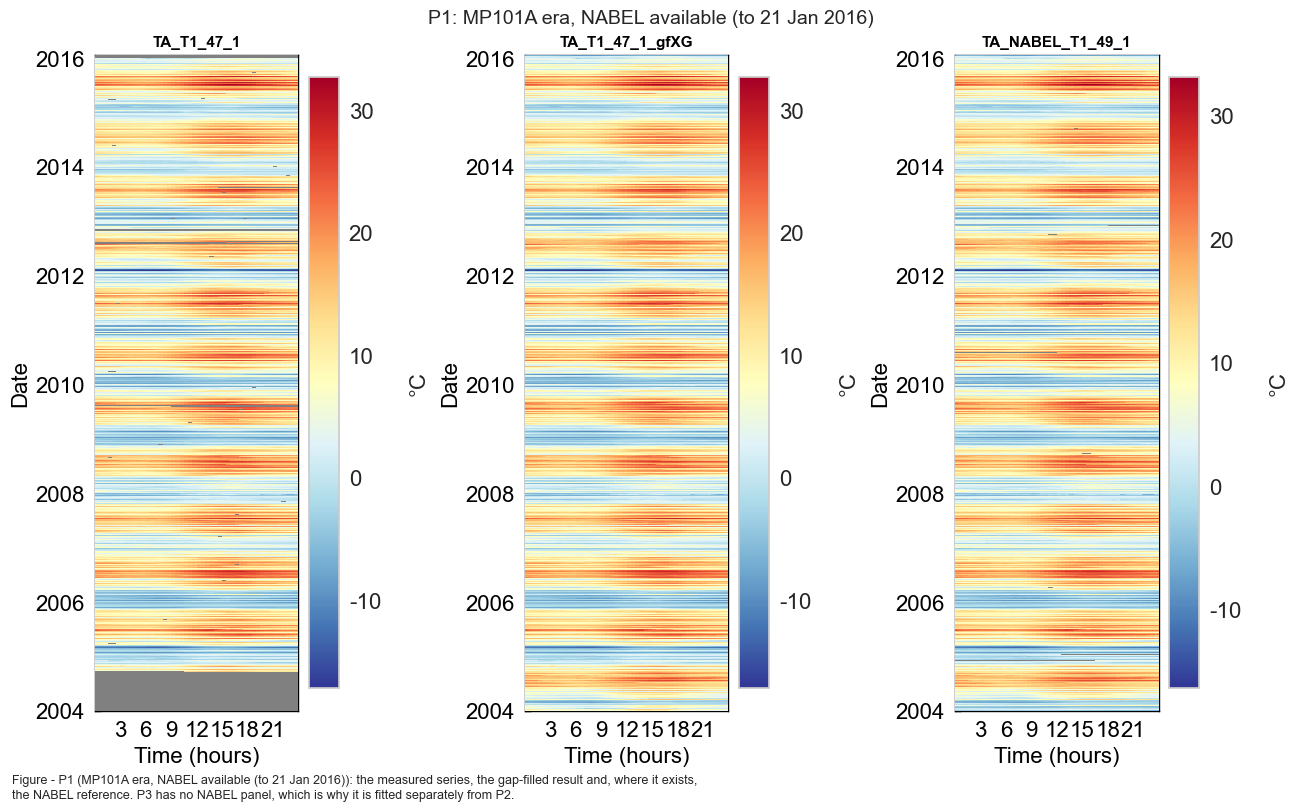

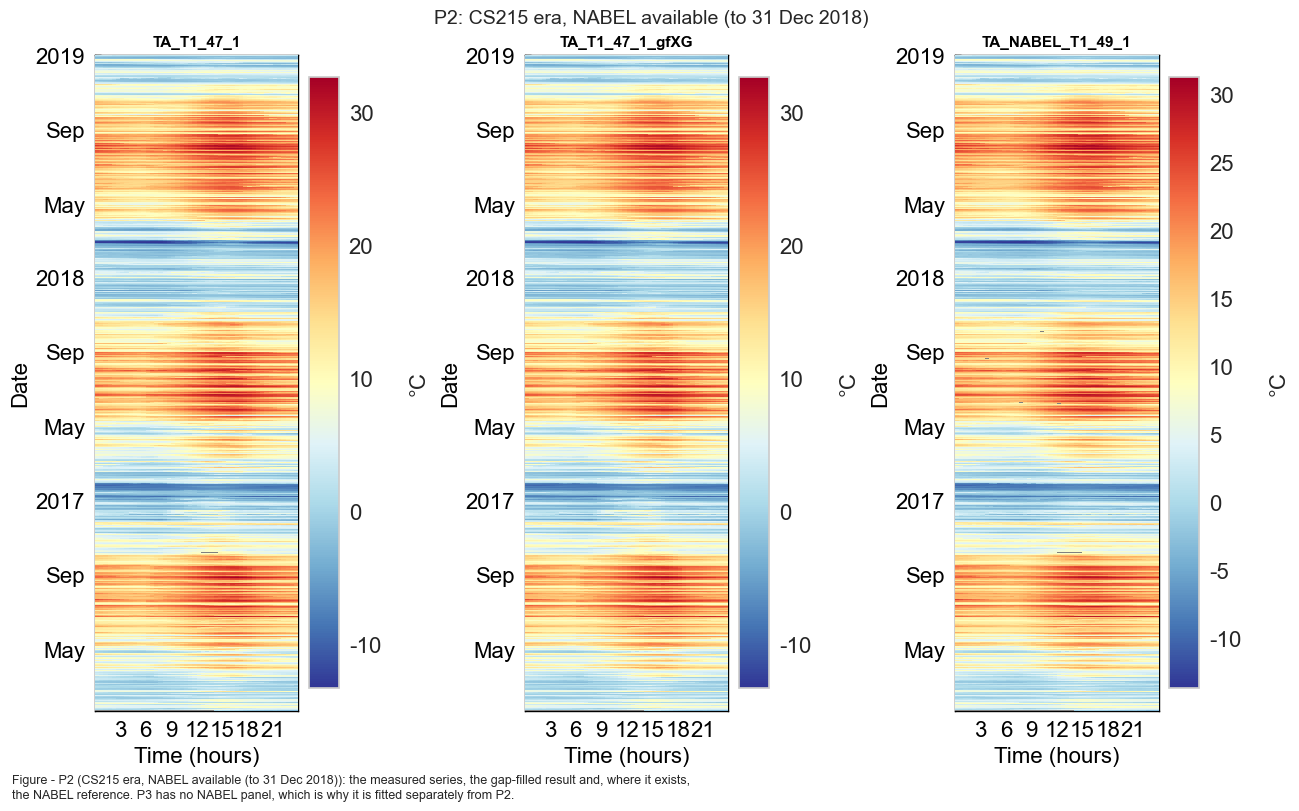

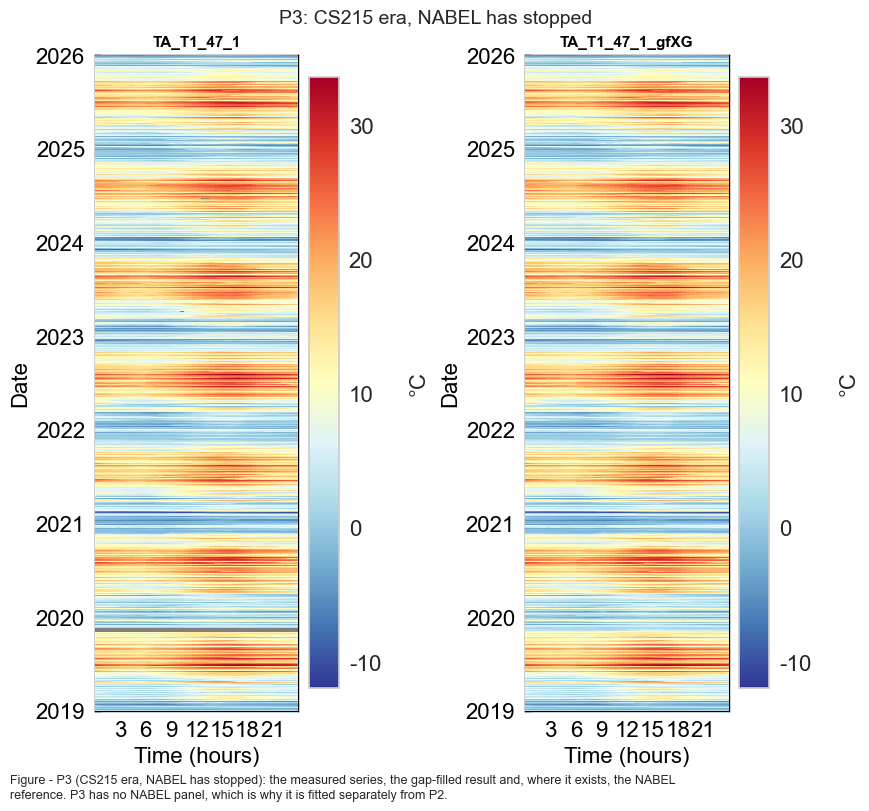

In [53]:
for _key, _r in results.items():
    _cols = [c for c in ['TA_T1_47_1', 'TA_T1_47_1_gfXG', 'TA_NABEL_T1_49_1']
             if c in _r['ta'].columns or c == 'TA_T1_47_1_gfXG']
    _plotdf = _r['ta'].copy()
    _plotdf['TA_T1_47_1_gfXG'] = _r['gapfilled']
    fig, axs = plt.subplots(ncols=len(_cols), figsize=(4.3 * len(_cols), 8), dpi=100,
                            layout="constrained")
    fig.suptitle(f"{_key}: {_r['label']}", fontsize=14)
    for _ax, _col in zip(np.atleast_1d(axs), _cols):
        dv.plotting.HeatmapDateTime(series=_plotdf[_col]).plot(
            ax=_ax, cb_digits_after_comma=0, zlabel='°C',
            format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))
    figcap(fig, f"{_key} ({_r['label']}): the measured series, the gap-filled result and, where it "
                f"exists, the NABEL reference. P3 has no NABEL panel, which is why it is fitted "
                f"separately from P2.")


***

## ➡️ Prepare dataframe for export

In [54]:
VALCOL = "TA_T1_47_1_gfXG"
FLAGCOL = "FLAG_TA_T1_47_1_ISFILLED"
HOMOGCOL = "TA_T1_47_1_HOMOGENIZED_gfXG"
SOURCECOL = "FLAG_TA_T1_47_1_SOURCE"

# Values and flags come from the same fit per period, so they are paired before the periods are
# stacked. The periods were asserted above to tile the record exactly once.
export_df = pd.concat([pd.concat([_r['gapfilled'], _r['flag']], axis=1)
                       for _r in results.values()], axis=0)
export_df


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,7.687806,2
2004-01-01 00:45:00,7.687806,2
2004-01-01 01:15:00,7.430779,2
2004-01-01 01:45:00,7.430779,2
2004-01-01 02:15:00,6.550650,2
...,...,...
2025-12-31 21:45:00,-3.081644,0
2025-12-31 22:15:00,-3.084372,0
2025-12-31 22:45:00,-3.423939,0


### 🩹 Records the gap-filler could only fill from the clock

The XGBoost model predicts only where **every** feature is present. When one driver is missing the
record falls through to the timestamp-only fallback (`ISFILLED == 2`), which predicts from the
calendar and the time of day alone: it follows the season, but not the weather. Its signature is
visible in the values — one prediction per hour, written to both half-hours.

Almost all of these are **January 2004**, and the missing driver is MeteoSwiss Lägern, whose record
begins on 1 February 2004. NABEL, two metres above the target on the same tower, is present for
that month at 100 %. So the information to fill January properly was there all along; the model
simply could not use it, because it requires all of its features at once.

Those records are therefore reconstructed from NABEL directly, with a straight line fitted on the
measured records of the same sensor era — slope as well as offset, so the reconstruction carries
the weather rather than a climatology. They are re-coded `ISFILLED == 5`, because they are no
longer what code `2` describes. Records whose fallback was caused by NABEL itself being missing
cannot be repaired this way and keep code `2`.

The cell assigns rather than adjusts, so running it twice changes nothing.


In [55]:
# Fallback records that NABEL can repair. The fit is per sensor era: the tower-to-NABEL
# relationship differs between the two by the offset this notebook exists to document.
_nabel = ta_2004_2025['TA_NABEL_T1_49_1'].reindex(export_df.index)
_fallback = export_df[FLAGCOL] == FILL_FALLBACK
_measured = export_df[FLAGCOL] == FILL_OBSERVED

_eras = {'MP101A': export_df.index < BREAK, 'CS215': export_df.index >= BREAK}
_report = []
for _era_name, _era_mask in _eras.items():
    _fit = _measured & _era_mask & _nabel.notna()
    _fix = _fallback & _era_mask & _nabel.notna()
    if _fix.sum() == 0:
        _report.append({'era': _era_name, 'repairable': 0, 'slope': np.nan, 'intercept': np.nan,
                        'fitted on': int(_fit.sum())})
        continue
    assert _fit.sum() > 10_000, \
        f"{_era_name}: only {int(_fit.sum())} measured records with NABEL to fit on"
    _slope, _intercept = np.polyfit(_nabel[_fit].to_numpy(), export_df.loc[_fit, VALCOL].to_numpy(), 1)
    # A guard on the fit: the two sensors measure the same air, so the slope must be near one.
    assert 0.9 < _slope < 1.1, f"{_era_name}: tower-on-NABEL slope {_slope:.3f} is not near 1"
    # Assignment, not adjustment - re-running the cell reproduces the same values.
    export_df.loc[_fix, VALCOL] = _slope * _nabel[_fix] + _intercept
    export_df.loc[_fix, FLAGCOL] = FILL_FROM_NABEL
    _report.append({'era': _era_name, 'repairable': int(_fix.sum()), 'slope': _slope,
                    'intercept': _intercept, 'fitted on': int(_fit.sum())})
tabcap("the tower-on-NABEL fit used to reconstruct the timestamp-only fallback records, per sensor era, and how many records each era repaired")
display(pd.DataFrame(_report).set_index('era').round(4))

# Where they are. They are not all in January 2004, and a limitation stated as if they were
# would mislead anyone looking at another period.
_where = export_df.index[export_df[FLAGCOL] == FILL_FROM_NABEL]
tabcap("when the records reconstructed from NABEL sit. They are concentrated in January 2004 but not confined to it")
display(pd.Series(1, index=_where).groupby([_where.year, _where.month]).sum()
        .rename('records reconstructed from NABEL').to_frame())

_left = int((export_df[FLAGCOL] == FILL_FALLBACK).sum())
print(f"still on the timestamp-only fallback (NABEL missing too): {_left} records")
assert (export_df[FLAGCOL] == FILL_FROM_NABEL).sum() > 0, "no fallback record was reconstructed"


Table - the tower-on-NABEL fit used to reconstruct the timestamp-only fallback records, per sensor
era, and how many records each era repaired



,repairable,slope,intercept,fitted on
era,,,,
MP101A,1530,1.0133,-1.0693,195060
CS215,0,NaN,NaN,51600


Table - when the records reconstructed from NABEL sit. They are concentrated in January 2004 but not
confined to it



records reconstructed from NABEL
TIMESTAMP_MIDDLE TIMESTAMP_MIDDLE                                  
2004             1                                             1488
                 2                                                1
2012             7                                               41

still on the timestamp-only fallback (NABEL missing too): 43 records


In [56]:
# The homogenised column. Two corrections, acting on different eras and derived in the break
# section above:
#   - the constant of step 8, added to the MP101A era, which puts both eras on one night level;
#   - the radiative excess of the CS215 shield, subtracted from the CS215 era, which puts them on
#     one daytime behaviour.
# The measured column is not touched beyond the NABEL reconstruction above - a rescaling that
# overwrote it would leave no way to recover what the sensor reported.
#
# Both are applied to modelled records as well as to measured ones. That is valid because no model
# spans the sensor change, so every filled record sits on the era it belongs to; because the
# records reconstructed from NABEL were fitted on their own era's measurements; and because the
# radiative term is a function of the same SW_IN the models used as a driver. The audit below
# measures the first per year and per fill method.
_sw_export = swin_gf[SWIN_COL].reindex(export_df.index)
assert _sw_export.notna().all(), (
    "SW_IN is missing on part of the export index, so the shield term cannot be applied there")
export_df[HOMOGCOL] = homogenize(export_df[VALCOL], export_df.index, _sw_export)
export_df[SOURCECOL] = source_flag.reindex(export_df.index).astype(int)

export_df = export_df[[VALCOL, FLAGCOL, HOMOGCOL, SOURCECOL]]
export_df


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,TA_T1_47_1_HOMOGENIZED_gfXG,FLAG_TA_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,-3.771351,5,-2.451677,3
2004-01-01 00:45:00,-3.670024,5,-2.350349,3
2004-01-01 01:15:00,-3.636248,5,-2.316573,3
2004-01-01 01:45:00,-3.737576,5,-2.417901,3
2004-01-01 02:15:00,-3.906455,5,-2.586781,3
...,...,...,...,...
2025-12-31 21:45:00,-3.081644,0,-3.081644,0
2025-12-31 22:15:00,-3.084372,0,-3.084372,0
2025-12-31 22:45:00,-3.423939,0,-3.423939,0


Sanity checks: both value columns must be complete (no gaps), the index must be continuous
30MIN with no duplicates, and every record must carry both flags. Unlike `SW_IN` there is no
non-negativity check — air temperature is negative for a good part of the year.

Beyond the structural checks, the correction is **audited against the evidence that produced it**.
Two things are asserted rather than assumed: that the homogenised column differs from the measured
one by exactly the offset and only before the break, and that the correction actually removes the
step it was derived to remove. The second is the one that matters — a correction that leaves the
night-time discontinuity in place would be worse than none, because it would look as though the
break had been handled.


In [57]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()} ({VALCOL})")
print(f"Missing values:  {export_df[HOMOGCOL].isnull().sum()} ({HOMOGCOL})")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()} / {export_df[SOURCECOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} degC")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
_pct = 100 * _counts / len(export_df)
tabcap("how each exported record was produced, by fill method")
display(pd.DataFrame({'count': _counts, '%': _pct.round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

print("\nSensor provenance:")
_sc = export_df[SOURCECOL].value_counts().sort_index()
tabcap("which sensor and acquisition system each exported record belongs to")
display(pd.DataFrame({'count': _sc, '%': (100 * _sc / len(export_df)).round(2)}
                     ).rename(index=FLAG_SOURCE_LEGEND))

# --- structural checks ------------------------------------------------------------------------
assert export_df[VALCOL].notna().all() and export_df[HOMOGCOL].notna().all(), \
    "a gap-filled column must not contain missing values"
assert export_df[FLAGCOL].isin(FLAG_LEGEND).all(), "unknown code in the fill flag"
assert export_df[SOURCECOL].isin(FLAG_SOURCE_LEGEND).all(), "unknown code in the source flag"

# --- the homogenisation is exactly what it claims to be ---------------------------------------
_delta = export_df[HOMOGCOL] - export_df[VALCOL]
_pre, _post = export_df.index < BREAK, export_df.index >= BREAK
assert np.allclose(_delta[_pre], OFFSET), \
    "the pre-break era was not shifted by exactly the derived offset"
assert np.allclose(_delta[_post], -radiative_excess(_sw_export[_post])), \
    "the post-break era does not carry exactly the radiative excess derived in the break section"
# The shield term acts in daylight only, so a CS215 record with no sun must be untouched. This is
# what keeps the night level of step 8 intact, and it is the first thing a wrong sign would break.
_dark = _post & (_sw_export <= 0)
assert _dark.sum() > 50_000, f"only {int(_dark.sum())} dark records in the CS215 era to check"
assert np.allclose(_delta[_dark], 0.0), \
    "a CS215 record with no incoming radiation was modified by the shield term"
# And the term can only ever cool the later era, by a bounded amount.
assert (_delta[_post] <= 1e-9).all(), "the shield term warmed a record of the CS215 era"
assert _delta[_post].min() > -1.5, \
    f"the shield term removes up to {-_delta[_post].min():.2f} degC, far more than it was fitted to"
assert (export_df.loc[export_df.index < BREAK, SOURCECOL] != SOURCE_CS215).all(), \
    "a record before the break is flagged as the CS215 era"
assert (export_df.loc[export_df.index >= BREAK, SOURCECOL] == SOURCE_CS215).all(), \
    "a record after the break is not flagged as the CS215 era"

# --- the break year is corrected like any other ------------------------------------------------
# The assertions above are on the whole record and would pass on a product that treated the break
# year specially, because that year is a fraction of a percent of it. It is therefore checked on
# its own, and on both sides of the changeover. Its first three weeks are the outage: no sensor
# produced them, every one of them is modelled on the MP101A period's level, and they carry the
# constant. Source code 2 says the sensor era is undetermined - not that the record is left
# uncorrected. From the changeover onwards the year is CS215 and carries the shield term instead.
_bk_before = (export_df.index.year == BREAK.year) & (export_df.index < BREAK)
_bk_after = (export_df.index.year == BREAK.year) & (export_df.index >= BREAK)
assert _bk_before.sum() > 0 and _bk_after.sum() > 0, \
    "the break year does not straddle the break, so it cannot be checked on both sides"
assert np.allclose(_delta[_bk_before], OFFSET), \
    "the part of the break year before the changeover did not receive the constant"
assert np.allclose(_delta[_bk_after], -radiative_excess(_sw_export[_bk_after])), \
    "the part of the break year after the changeover does not carry exactly the shield term"
assert (export_df.loc[_bk_before, SOURCECOL] == SOURCE_CHANGEOVER).all(), \
    "the break year before the changeover is not flagged as the changeover"
assert np.allclose(_delta[export_df[SOURCECOL] == SOURCE_CHANGEOVER], OFFSET), \
    "a changeover record did not receive the constant - the outage that contains the sensor swap " \
    "is modelled on the MP101A level and must be corrected onto the CS215 level like the rest of " \
    "that era"

# --- the correction removes the step it was derived to remove ---------------------------------
# Re-derived here from the exported column against NABEL, not carried over from the section above,
# so that a change anywhere between the two is caught.
_audit = pd.concat([export_df[HOMOGCOL], export_df[VALCOL],
                    ta_2004_2025['TA_NABEL_T1_49_1']], axis=1).dropna()
_audit = _audit[NIGHT.reindex(_audit.index).fillna(False)]
_before = _audit.loc[:LAST_BEFORE]
_after = _audit.loc[BREAK:'2018']
for _col, _label in [(VALCOL, 'measured   '), (HOMOGCOL, 'homogenised')]:
    _step = ((_after[_col] - _after['TA_NABEL_T1_49_1']).mean()
             - (_before[_col] - _before['TA_NABEL_T1_49_1']).mean())
    print(f"\nNight-time step against NABEL, {_label}: {_step:+.3f} degC")
    if _col == HOMOGCOL:
        assert abs(_step) < 0.15, (
            f"the homogenised column still steps by {_step:+.3f} degC at the break - the "
            f"correction did not do what it was derived to do")

export_df.describe()


Records:         385728
Missing values:  0 (TA_T1_47_1_gfXG)
Missing values:  0 (TA_T1_47_1_HOMOGENIZED_gfXG)
Missing flags:   0 / 0
Duplicate index: 0
Index gaps:      0
Min / max:       -17.20 / 33.56 degC

Fill provenance:
Table - how each exported record was produced, by fill method



,count,%
FLAG_TA_T1_47_1_ISFILLED,,
0 = observed,369065,95.68
1 = gap-filled by the XGBoost model,14912,3.87
2 = gap-filled by the timestamp-only fallback model (a driver was missing),43,0.01
4 = gap-filled by linear interpolation (short gap),178,0.05
5 = reconstructed from NABEL at 49 m on the same tower (the model lacked a driver),1530,0.40


Measured: 95.68%  |  Filled: 4.32%

Sensor provenance:
Table - which sensor and acquisition system each exported record belongs to



,count,%
FLAG_TA_T1_47_1_SOURCE,,
"0 = Campbell CS215, SDI-12, 21 Jan 2016 onwards (the reference era of the homogenisation)",174356,45.20
"1 = Rotronic MP101A, analog single-ended, 2004 - 31 Dec 2015 (reads about 1.3 degC low)",197739,51.26
"2 = acquisition changeover, 01 - 21 Jan 2016: no measurement, sensor era undetermined",988,0.26
"3 = before the tower record begins (2004): no measurement, values are modelled throughout",12645,3.28



Night-time step against NABEL, measured   : +1.313 degC

Night-time step against NABEL, homogenised: -0.007 degC


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,TA_T1_47_1_HOMOGENIZED_gfXG,FLAG_TA_T1_47_1_SOURCE
count,385728.000000,385728.000000,385728.000000,385728.000000
mean,8.939648,0.060561,9.590498,0.616108
std,8.173391,0.376808,8.062759,0.662069
min,-17.200001,0.000000,-15.880326,0.000000
25%,2.578000,0.000000,3.322176,0.000000
50%,8.883216,0.000000,9.539369,1.000000
75%,15.000000,0.000000,15.649557,1.000000
max,33.558765,5.000000,33.969676,3.000000


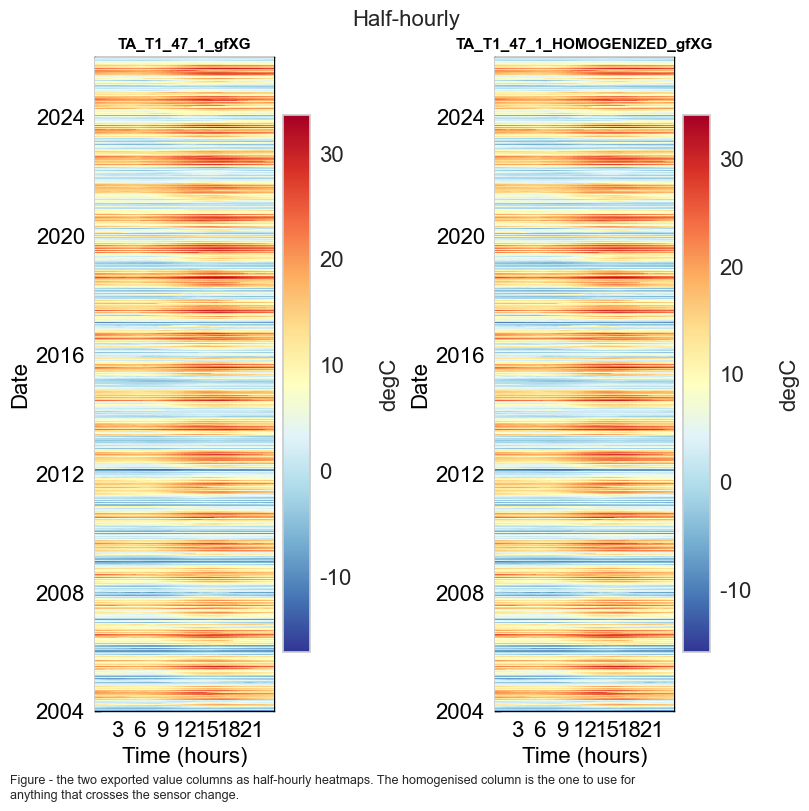

In [58]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 8), dpi=100, layout="constrained")
fig.suptitle('Half-hourly', fontsize=16)
for _ax, _col in zip(axs, [VALCOL, HOMOGCOL]):
    dv.plotting.HeatmapDateTime(series=export_df[_col]).plot(
        ax=_ax, cb_digits_after_comma=0, zlabel='degC',
        format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))
figcap(fig, "the two exported value columns as half-hourly heatmaps. The homogenised column is the "
            "one to use for anything that crosses the sensor change.")

#### Does the reconstruction method work? A month where the answer is known

Both tests in the audit further below are structurally satisfied for the reconstructed records:
their level agrees with NABEL because they were fitted to it, and their scatter around NABEL is
small for the same reason. Neither can fail, so neither is evidence.

What can fail is the **method**. The line is refitted here *without* January, and used to predict
the measured Januaries of the same era — the same operation performed above, on eleven months where
the true values exist. The residual against those measurements is a real error estimate, and it is
compared against the scatter two co-located sensors show anyway, which is the floor no
reconstruction can beat.


In [59]:
# Refit without January, predict the measured Januaries of the MP101A era.
_m = (export_df[FLAGCOL] == FILL_OBSERVED) & (export_df.index < BREAK) & _nabel.notna()
_jan = _m & (export_df.index.month == 1)
_rest = _m & (export_df.index.month != 1)
assert _jan.sum() > 5_000, f"only {int(_jan.sum())} measured January records to test on"

_s_ho, _i_ho = np.polyfit(_nabel[_rest].to_numpy(), export_df.loc[_rest, VALCOL].to_numpy(), 1)
_resid = export_df.loc[_jan, VALCOL] - (_s_ho * _nabel[_jan] + _i_ho)
_floor = (export_df.loc[_m, VALCOL] - _nabel[_m]).std()   # sensor-to-sensor scatter, all hours

print(f"fitted without January on {int(_rest.sum()):,} records: "
      f"slope {_s_ho:.4f}, intercept {_i_ho:+.4f}")
print(f"predicting {int(_jan.sum()):,} measured January records "
      f"({export_df.index[_jan].year.min()}-{export_df.index[_jan].year.max()}):")
print(f"  bias {_resid.mean():+.3f} degC | RMSE {np.sqrt((_resid ** 2).mean()):.3f} degC")
print(f"  scatter between the two sensors anyway (the floor): {_floor:.3f} degC")
tabcap("the hold-out test of the NABEL reconstruction: a fit made without January, predicting the measured Januaries it never saw, per year")
display(_resid.groupby(_resid.index.year).agg(records='count', bias='mean').round(3))

# The reconstruction line is fitted over all hours and applied to a whole month, so the daytime
# has to be checked as well: the two sensors' shields differ, and that difference is a daytime one.
for _when, _mask in [('night', NIGHT.reindex(_resid.index).fillna(False)),
                     ('day  ', ~NIGHT.reindex(_resid.index).fillna(False))]:
    _r = _resid[_mask]
    print(f"  {_when}: bias {_r.mean():+.3f} degC | RMSE {np.sqrt((_r ** 2).mean()):.3f} degC "
          f"(n={len(_r):,})")

assert abs(_resid.mean()) < 0.25, (
    f"reconstructing a January from NABEL is biased by {_resid.mean():+.3f} degC - the line fitted "
    f"on the rest of the year does not transfer to winter")
assert np.sqrt((_resid ** 2).mean()) < 2 * _floor, (
    f"reconstruction RMSE {np.sqrt((_resid ** 2).mean()):.3f} degC is more than twice the "
    f"{_floor:.3f} degC the two sensors differ by anyway")


fitted without January on 178,832 records: slope 1.0149, intercept -1.0889
predicting 16,228 measured January records (2005-2015):
  bias +0.063 degC | RMSE 0.415 degC
  scatter between the two sensors anyway (the floor): 0.380 degC
Table - the hold-out test of the NABEL reconstruction: a fit made without January, predicting the
measured Januaries it never saw, per year



,records,bias
TIMESTAMP_MIDDLE,,
2005,1367,0.225
2006,1486,0.282
2007,1487,-0.111
2008,1487,-0.031
2009,1487,0.164
2010,1487,0.099
2011,1488,0.156
2012,1487,0.102
2013,1478,0.094


  night: bias -0.027 degC | RMSE 0.299 degC (n=9,998)
  day  : bias +0.207 degC | RMSE 0.552 degC (n=6,230)


#### Every modelled record sits on the era it belongs to, and varies like it

The offset is added to every pre-break record, modelled ones included, which is valid only if the
modelled values share the measured era's level. Two things are checked, and the second is the one
that carries the weight.

**Level, per year and per fill method.** Not per year alone: an average over a year hides two
opposite errors that cancel, which is exactly how a earlier version of this notebook passed while
holding 11,150 records 1.1 °C too cold and 1,495 records 5.5 °C too warm. Splitting by fill method
separates populations that were produced by different models and have no reason to agree.

**Spread.** A level test cannot catch a fill that has the right mean and no weather in it: a
timestamp-only climatology scatters against NABEL several degrees more widely than a measurement
does, and the spread gate is what catches that.

**Neither test is evidence for the records reconstructed from NABEL.** Their level agrees with it
because they were fitted to it, and their scatter around it is *smaller* than a measurement's for
the same reason — a fitted line carries no residual. Both gates pass them by construction. What
supports those records instead is the slope guard on the fit above, and the held-out January test
in the previous section, which can fail.


In [60]:
# Night bias against NABEL for everything before the break, by year and fill method.
_chk = pd.concat([export_df[[VALCOL, FLAGCOL]], ta_2004_2025['TA_NABEL_T1_49_1']],
                 axis=1).dropna()
_chk = _chk[NIGHT.reindex(_chk.index).fillna(False) & (_chk.index < BREAK)]
_chk['bias'] = _chk[VALCOL] - _chk['TA_NABEL_T1_49_1']
_chk['YEAR'] = _chk.index.year

_ref = _chk[_chk[FLAGCOL] == FILL_OBSERVED]['bias']
LEVEL, SPREAD = _ref.mean(), _ref.std()
print(f"measured MP101A era at night: level {LEVEL:+.3f} degC, spread (SD) {SPREAD:.3f} degC "
      f"(n={len(_ref):,})")

_tab = (_chk.groupby(['YEAR', FLAGCOL])['bias']
        .agg(records='count', level='mean', spread='std'))
_tab['level departure'] = (_tab['level'] - LEVEL).abs()
_tab['spread ratio'] = _tab['spread'] / SPREAD
_tab = _tab.rename(index=FLAG_LEGEND, level=1)
tabcap("the night bias against NABEL before the break, by year and fill method. Populations produced by different models have no reason to agree, so each is tested on its own")
display(_tab.round(2))

# Assert per (year, fill method) group that is large enough for its statistics to mean anything.
TOLERANCE, SPREAD_RATIO_MAX, MIN_NIGHTS = 0.5, 5.0, 100
_tested = []
for (_yr, _flag), _row in _tab.iterrows():
    if _row['records'] < MIN_NIGHTS or _flag == FLAG_LEGEND[FILL_OBSERVED]:
        continue
    _tested.append((_yr, _flag.split(' = ')[0]))
    assert _row['level departure'] < TOLERANCE, (
        f"{_yr}, fill method {_flag!r}: sits {_row['level departure']:.2f} degC from the measured "
        f"level of its era. The homogenisation offset is not valid for those records.")
    assert _row['spread ratio'] < SPREAD_RATIO_MAX, (
        f"{_yr}, fill method {_flag!r}: scatters {_row['spread ratio']:.1f}x more widely against "
        f"NABEL than the measurements do. Those values carry a season but not the weather.")
_first_year = int(_chk['YEAR'].min())
assert any(_y == _first_year for _y, _ in _tested), (
    f"{_first_year} was not tested: no modelled group reached {MIN_NIGHTS} night records. That is "
    f"the year with most of the record's fills, so a check that skips it is not checking the "
    f"thing it exists for.")
print(f"OK: {len(_tested)} (year, fill method) groups tested - {_tested}")


measured MP101A era at night: level -1.084 degC, spread (SD) 0.250 degC (n=93,754)
Table - the night bias against NABEL before the break, by year and fill method. Populations produced
by different models have no reason to agree, so each is tested on its own



records  level  spread  level departure  spread ratio
YEAR FLAG_TA_T1_47_1_ISFILLED                                                                                 
2004 0 = observed                                           2812  -0.85    0.27             0.23          1.06
     1 = gap-filled by the XGBoost model                    4638  -0.76    0.19             0.32          0.75
     5 = reconstructed from NABEL at 49 m on the sam...      918  -1.08    0.05             0.00          0.20
2005 0 = observed                                           8236  -0.97    0.23             0.11          0.90
     4 = gap-filled by linear interpolation (short gap)        3  -0.92    0.27             0.16          1.06
2006 0 = observed                                           8352  -1.08    0.21             0.00          0.86
     1 = gap-filled by the XGBoost model                       9  -1.28    0.08             0.19          0.32
     4 = gap-filled by linear interpolation (short gap)        4  -1.10    0.35             0.02          1.40
2007 0 = observed                                           8356  -1.11    0.22             0.03          0.90
     4 = gap-filled by linear interpolation (short gap)        6  -1.05    0.24             0.03          0.95
2008 0 = observed                                           8391  -1.15    0.22             0.06          0.88
     4 = gap-filled by linear interpolation (short gap)        8  -1.29    0.31             0.20          1.24
2009 0 = observed                                           8182  -1.16    0.21             0.07          0.85
     1 = gap-filled by the XGBoost model                     176  -0.97    0.11             0.12          0.43
     4 = gap-filled by linear interpolation (short gap)        8  -1.08    0.22             0.01          0.89
2010 0 = observed                                           8278  -1.04    0.20             0.05          0.81
     1 = gap-filled by the XGBoost model                      48  -0.79    0.16             0.30          0.64
     4 = gap-filled by linear interpolation (short gap)        7  -1.19    0.11             0.11          0.46
2011 0 = observed                                           8361  -1.02    0.24             0.07          0.95
     4 = gap-filled by linear interpolation (short gap)        6  -1.11    0.09             0.02          0.37
2012 0 = observed                                           7740  -1.05    0.23             0.03          0.90
     1 = gap-filled by the XGBoost model                     581  -0.97    0.15             0.11          0.61
     4 = gap-filled by linear interpolation (short gap)        5  -1.31    0.33             0.23          1.31
     5 = reconstructed from NABEL at 49 m on the sam...       11  -0.85    0.01             0.23          0.02
2013 0 = observed                                           8326  -1.05    0.20             0.03          0.79
     1 = gap-filled by the XGBoost model                      18  -0.96    0.09             0.12          0.37
     4 = gap-filled by linear interpolation (short gap)       22  -1.12    0.28             0.04          1.14
2014 0 = observed                                           8358  -1.30    0.35             0.22          1.41
     4 = gap-filled by linear interpolation (short gap)        9  -1.23    0.26             0.14          1.03
2015 0 = observed                                           8362  -1.06    0.18             0.03          0.73
     4 = gap-filled by linear interpolation (short gap)        6  -1.15    0.31             0.07          1.22
2016 1 = gap-filled by the XGBoost model                     614  -1.19    0.17             0.11          0.67

OK: 5 (year, fill method) groups tested - [(2004, '1'), (2004, '5'), (2009, '1'), (2012, '1'), (2016, '1')]


***

#### The same figures from the finished columns

The break section computes these from **measured records only**, so that the gap-filling cannot
influence the argument. A user follows the note below and computes them from the **exported
columns**, which include the 4 % that is modelled — and gets slightly different numbers. Both are
shown here rather than leaving the reader to discover the discrepancy.

Neither is more correct. Measured-only is free of the model but seasonally biased wherever a year's
gaps cluster in one season; the complete columns have no sampling bias but carry the model. The
difference between them is a fair measure of how much the gap-filling moves these statistics.


In [61]:
_yp = export_df[[VALCOL, HOMOGCOL]].resample('YE').mean()
_yp.index = _yp.index.year
_yp = _yp.loc[2005:]
_e, _r = _yp.index < BREAK.year, _yp.index > BREAK.year

_rows = []
for _col, _name in [(VALCOL, 'as measured'), (HOMOGCOL, 'homogenised')]:
    _s = _yp[_col]
    _slope, _, _lo, _hi = theilslopes(_s.to_numpy(float), _s.index.to_numpy(float), alpha=0.95)
    _tau, _p = kendalltau(_s.index.to_numpy(float), _s.to_numpy(float))
    _rows.append({'series': _name,
                  f'{_yp.index.min()}-{BREAK.year - 1} (degC)': _s[_e].mean(),
                  f'{BREAK.year + 1}-{_yp.index.max()} (degC)': _s[_r].mean(),
                  'difference (degC)': _s[_r].mean() - _s[_e].mean(),
                  'Theil-Sen (degC/decade)': _slope * 10,
                  'lower 95 %': _lo * 10, 'upper 95 %': _hi * 10,
                  'Kendall tau': _tau, 'p': _p})
headline_product = pd.DataFrame(_rows).set_index('series')

_both = pd.concat([headline_measured.assign(computed_from='measured records only'),
                   headline_product.assign(computed_from='the exported columns')])
tabcap("the headline period difference and trend computed two ways: from measured records only, and from the complete exported columns. They disagree because a measured-only mean is seasonally biased wherever a year's gaps cluster")
display(_both.set_index('computed_from', append=True).round(3))

_gap = abs(headline_product.loc['homogenised', 'difference (degC)']
           - headline_measured.loc['homogenised', 'difference (degC)'])
print(f"The two ways of computing the homogenised period difference disagree by {_gap:.3f} degC, "
      f"which is\nthe influence of the {100 * (export_df[FLAGCOL] > 0).mean():.1f} % of the "
      f"product that is modelled. Both are reported; neither is\nsuppressed.")
assert _gap < 0.5, (
    f"the gap-filled and measured-only headline figures differ by {_gap:.2f} degC - large enough "
    f"that the modelled records, not the sensors, would be driving the reported difference")


Table - the headline period difference and trend computed two ways: from measured records only, and
from the complete exported columns. They disagree because a measured-only mean is seasonally biased
wherever a year's gaps cluster



,,2005-2015 (degC),2017-2025 (degC),difference (degC),Theil-Sen (degC/decade),lower 95 %,upper 95 %,Kendall tau,p
series,computed_from,,,,,,,,
as measured,measured records only,7.848,10.323,2.475,1.802,1.160,2.483,0.590,0.000
homogenised,measured records only,9.168,10.163,0.995,0.767,0.290,1.282,0.467,0.003
as measured,the exported columns,7.904,10.293,2.390,1.757,1.313,2.363,0.629,0.000
homogenised,the exported columns,9.223,10.134,0.911,0.764,0.338,1.280,0.467,0.003


The two ways of computing the homogenised period difference disagree by 0.084 degC, which is
the influence of the 4.3 % of the product that is modelled. Both are reported; neither is
suppressed.


***

## 📘 Note for downstream users

**Which column to use.**

- Anything that stays inside one sensor era can use `TA_T1_47_1_gfXG`, which is what the instrument
  reported.
- Anything that **crosses 21 January 2016** — a period mean, a trend, a ranking of years, an
  anomaly against a multi-year reference — must use `TA_T1_47_1_HOMOGENIZED_gfXG`. The measured
  column steps by about 1.3 °C at that date for instrumental reasons, and the step exceeds the
  climate signal over this record.
- The homogenised column differs from the measured one **in both eras**: before the break by a
  constant, after it by a radiation-dependent amount that is zero at night and largest in strong
  sun. Differencing the two columns therefore returns the correction, not a constant.

**Which flag to filter on.**

- `FLAG_TA_T1_47_1_ISFILLED == 0` selects measured records. The series is complete, so every other
  record is a model result. Code `5` marks records reconstructed from NABEL on the same tower, and
  code `2` the few that could only be filled from the clock.
- `FLAG_TA_T1_47_1_SOURCE` names the sensor: `1` is the Rotronic MP101A era and `0` the Campbell
  CS215 era. Two codes mark records no sensor produced — `2`, the 988 records of the January 2016
  outage, which belong to neither era, and `3`, the months before the tower record begins in
  September 2004. **`source > 1` is everything that no instrument stands behind**; drop it if
  provenance has to be certain.

Both value columns share the same fill flag and the same source flag: the homogenisation changes
values, never provenance.

**Known limitations of the homogenised column.** It standardises the later era onto the earlier
era's radiation shield, so what remains is the shield error the two sensors **share**: both read
warm in sun and light wind relative to an aspirated measurement, across the whole record. Daily
maxima and diurnal ranges are therefore biased warm throughout — but they are biased by a
comparable amount on both sides of 2016, which is what the column is for. The residual step that
does survive is measured in *What the correction does not fix* above, on every run.

Two further limitations that the homogenisation does not address: the records reconstructed from
NABEL carry too little scatter, so statistics of spread over the periods they cover are
understated; and 2004 has no measurement before 20 September. Both are detailed in the same
section.

The evidence for all of this is re-derived on every run in the section *The 2016 acquisition
break*. Nothing in this note is a quoted figure.


## 💾 Save to file

In [62]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.082 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\02_METEO_TA_GAPFILLED_2004-2025.parquet


***

## End of notebook.

In [63]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-28 19:15:13
Finished: 2026-07-28 19:22:20
Runtime:  00:07:06 (hh:mm:ss)
